# Capstone Project Guide

This notebook is your runway into the **Regime-Shift: Macro-Aware Tactical Asset Allocation Engine** capstone. Every section is chosen because you will use it directly in the project: pulling multi-asset data, engineering features that describe *market regimes*, building and validating an HMM, and avoiding the single most common way quant projects quietly fail - **lookahead bias**.

**Sections**

1. Environment & imports
2. NumPy
3. Pandas
4. Feature engineering
5. Matplotlib
6. yfinance
7. The lookahead bias problem (and why it kills backtests)
8. Walk-forward validation
9. ML primer


---
## 1. Environment & Imports

Run this cell first. If any import fails, install the missing package with `pip install <package>` in a terminal (or `!pip install <package>` in a notebook cell) and re-run.

The project's tech stack is: `numpy`, `pandas`, `matplotlib`, `yfinance`, `scipy`, `hmmlearn`, `cvxpy`. We'll also touch `scikit-learn` and `torch` (PyTorch) since "ML" in the goals list extends beyond just HMMs. You'll want this for any feature-based classifiers or experimentation you do beyond the core HMM regime classifier.

In [35]:
pip install hmmlearn scikit-learn torch cvxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.6 MB/s eta 0:00:00


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Market data
import yfinance as yf

# Stats / scientific
import scipy.stats as stats

# Will be used later in the notebook so install if missing:
# pip install hmmlearn scikit-learn torch cvxpy
try:
    from hmmlearn import hmm
    HMM_OK = True
except ImportError:
    HMM_OK = False
    print("hmmlearn not installed - install with `pip install hmmlearn` before Section 9")

try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
except ImportError:
    TORCH_OK = False
    print("torch not installed - install with `pip install torch` before the PyTorch primer")

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Environment ready.")


Environment ready.


---
## 2. NumPy

Pandas, scikit-learn, hmmlearn, and PyTorch are all built on top of NumPy arrays internally. When you call `.values` or `.to_numpy()` on a DataFrame, or when an HMM spits out a covariance matrix, you're in NumPy territory. You need fluency here for three reasons specific to this project:

1. **Vectorized math** — computing returns, log-returns, z-scores across thousands of rows without Python loops (loops are slow and, worse, easy to get subtly wrong with time-series data).
2. **Matrix operations** — covariance matrices, the core object in Markowitz-style optimization (`cvxpy` will consume these directly).
3. **Random state control** — HMMs are fit with random initializations; reproducibility requires you to understand `np.random.seed`.


In [37]:
# --- Arrays vs lists ---
prices_list = [100, 101, 99, 103, 105]
prices_arr = np.array(prices_list)

print(type(prices_list), type(prices_arr))
print(prices_arr * 1.1)        # vectorized — try this with a plain list, it breaks
print(prices_arr.mean(), prices_arr.std())


<class 'list'> <class 'numpy.ndarray'>
[110.  111.1 108.9 113.3 115.5]
101.6 2.1540659228538015


In [38]:
# --- Returns: the first transformation you'll do to ANY price series ---
prices = np.array([100, 102, 101, 105, 107, 104])

# simple returns
simple_returns = prices[1:] / prices[:-1] - 1

# log returns (preferred in quant work - additive across time, better statistical properties)
log_returns = np.diff(np.log(prices))

print("Simple returns:", np.round(simple_returns, 4))
print("Log returns:   ", np.round(log_returns, 4))

# Why log returns? They sum cleanly across time:
print("\nSum of log returns:", log_returns.sum())
print("Equivalent total log return:", np.log(prices[-1] / prices[0]))


Simple returns: [ 0.02   -0.0098  0.0396  0.019  -0.028 ]
Log returns:    [ 0.0198 -0.0099  0.0388  0.0189 -0.0284]

Sum of log returns: 0.039220713153280684
Equivalent total log return: 0.03922071315328133


In [39]:
# --- Matrices: covariance is the backbone of portfolio optimization ---
np.random.seed(42)

# simulate 3 correlated asset return streams (250 trading days)
n_days = 250
mean_returns = np.array([0.0005, 0.0003, 0.0001])   # equities, bonds, gold (daily)
cov_matrix = np.array([
    [0.00040, -0.00005,  0.00002],
    [-0.00005, 0.00010,  0.00001],
    [0.00002,  0.00001,  0.00015],
])

simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, size=n_days)
print("Simulated returns shape:", simulated_returns.shape)

# recover the covariance matrix from data as this is what you'll do with REAL returns later
estimated_cov = np.cov(simulated_returns, rowvar=False)
print("\nEstimated covariance matrix:\n", np.round(estimated_cov, 6))


Simulated returns shape: (250, 3)

Estimated covariance matrix:
 [[ 3.25e-04 -3.00e-05  3.00e-06]
 [-3.00e-05  9.90e-05  3.00e-06]
 [ 3.00e-06  3.00e-06  1.53e-04]]


In [40]:
# --- Boolean masking: how you will isolate regime periods ---
returns = np.array([0.01, -0.02, 0.015, -0.03, 0.005, -0.01, 0.02])

# "Crisis" mask: any day with a loss worse than -1.5%
crisis_mask = returns < -0.015
print("Crisis days mask:", crisis_mask)
print("Crisis day returns:", returns[crisis_mask])
print("Average crisis-day return:", returns[crisis_mask].mean())

# This exact pattern - boolean mask -> subset -> aggregate -- is how you will compute
# regime-conditional statistics later (e.g. "average vol when HMM says Bear").


Crisis days mask: [False  True False  True False False False]
Crisis day returns: [-0.02 -0.03]
Average crisis-day return: -0.025


### Try it
1. Generate 500 simulated daily log-returns from `np.random.normal(0.0003, 0.012, 500)`.
2. Compute the annualized return (`mean * 252`) and annualized volatility (`std * sqrt(252)`).
3. Using boolean masking, isolate days where the return is in the bottom 5% (`np.percentile`) and compute their average. This is a crude proxy for "tail risk" you'll later assign to the Crisis regime.


In [41]:
np.random.seed(42)
sim_returns = np.random.normal(0.0003, 0.012, 500)
ann_return = sim_returns.mean() * 252
ann_vol = sim_returns.std() * np.sqrt(252)
pct_5 = np.percentile(sim_returns, 5)
tail_days = sim_returns[sim_returns < pct_5]
tail_avg = tail_days.mean()
print(f"Annualized Return: {ann_return:.4f}")
print(f"Annualized Volatility: {ann_vol:.4f}")
print(f"5% Percentile Cutoff: {pct_5:.4f}")
print(f"Average Tail Return (Tail Risk): {tail_avg:.4f}")


Annualized Return: 0.0963
Annualized Volatility: 0.1867
5% Percentile Cutoff: -0.0179
Average Tail Return (Tail Risk): -0.0226


---
## 3. Pandas

If NumPy is the engine, Pandas is the dashboard. Every dataset in this project from equity prices, VIX to macro indicators arrive as a time-indexed table. Pandas' `DatetimeIndex` is what lets you align mismatched series (e.g. daily equities vs monthly CPI), resample frequencies, and shift data forward/backward in time which is *exactly* the skill that prevents lookahead bias.

Three pandas objects you must be fluent in:
- **Series** — one column, time-indexed (e.g. a single asset's daily returns)
- **DataFrame** — many columns sharing one time index (e.g. your multi-asset return matrix)
- **DatetimeIndex** — the index itself, which gives you `.resample()`, `.shift()`, `.rolling()`, `.expanding()`


In [7]:
# --- Building a time-indexed Series/DataFrame from scratch ---
dates = pd.date_range("2024-01-01", periods=10, freq="B")  # 'B' = business day frequency
prices = pd.Series([100, 101, 99, 103, 105, 104, 106, 108, 107, 110], index=dates, name="SPY")

print(prices)
print("\nIndex type:", type(prices.index))


2024-01-01    100
2024-01-02    101
2024-01-03     99
2024-01-04    103
2024-01-05    105
2024-01-08    104
2024-01-09    106
2024-01-10    108
2024-01-11    107
2024-01-12    110
Freq: B, Name: SPY, dtype: int64

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [8]:
# --- Returns the pandas way ---
returns = prices.pct_change()          # simple returns
log_returns = np.log(prices).diff()    # log returns

df = pd.DataFrame({"price": prices, "simple_ret": returns, "log_ret": log_returns})
print(df)

# Note row 0 is NaN — there's no "previous day" to compute a return from.
# ALWAYS check for and handle these NaNs explicitly; silently dropping or
# filling them wrong is a classic source of subtle bugs.


            price  simple_ret   log_ret
2024-01-01    100         NaN       NaN
2024-01-02    101    0.010000  0.009950
2024-01-03     99   -0.019802 -0.020001
2024-01-04    103    0.040404  0.039609
2024-01-05    105    0.019417  0.019231
2024-01-08    104   -0.009524 -0.009569
2024-01-09    106    0.019231  0.019048
2024-01-10    108    0.018868  0.018692
2024-01-11    107   -0.009259 -0.009302
2024-01-12    110    0.028037  0.027652


In [9]:
# --- .shift(): the single most important method for avoiding lookahead bias ---
# shift(1) moves data FORWARD in time (i.e., "what I knew yesterday")
df["price_lagged_1"] = df["price"].shift(1)

# shift(-1) moves data BACKWARD — i.e. peeking into the FUTURE.
# You will use this ONLY when explicitly constructing a forward-looking
# TARGET for supervised learning, never as a FEATURE.
df["price_next_day"] = df["price"].shift(-1)

print(df[["price", "price_lagged_1", "price_next_day"]])


            price  price_lagged_1  price_next_day
2024-01-01    100             NaN           101.0
2024-01-02    101           100.0            99.0
2024-01-03     99           101.0           103.0
2024-01-04    103            99.0           105.0
2024-01-05    105           103.0           104.0
2024-01-08    104           105.0           106.0
2024-01-09    106           104.0           108.0
2024-01-10    108           106.0           107.0
2024-01-11    107           108.0           110.0
2024-01-12    110           107.0             NaN


In [10]:
# --- Aligning multiple assets on a shared time index ---
dates2 = pd.date_range("2024-01-01", periods=10, freq="B")
spy = pd.Series(np.random.normal(0.0005, 0.01, 10).cumsum() + 100, index=dates2, name="SPY")
tlt = pd.Series(np.random.normal(0.0001, 0.005, 10).cumsum() + 100, index=dates2, name="TLT")
gld = pd.Series(np.random.normal(0.0002, 0.008, 10).cumsum() + 100, index=dates2, name="GLD")

multi_asset = pd.concat([spy, tlt, gld], axis=1)
print(multi_asset)

multi_returns = multi_asset.pct_change().dropna()
print("\nReturns:\n", multi_returns)
print("\nCorrelation matrix:\n", multi_returns.corr())


                   SPY         TLT        GLD
2024-01-01  100.009762  100.001452  99.986845
2024-01-02  100.029356  100.001301  99.991392
2024-01-03  100.015870  100.000206  99.986291
2024-01-04  100.022000   99.995769  99.991055
2024-01-05  100.015994   99.992985  99.985149
2024-01-08  100.011622   99.996862  99.970910
2024-01-09  100.006198   99.999466  99.958090
2024-01-10   99.998058   99.994678  99.958675
2024-01-11   99.999044   99.995275  99.960952
2024-01-12   99.991234   99.999132  99.953918

Returns:
                  SPY       TLT       GLD
2024-01-02  0.000196 -0.000002  0.000045
2024-01-03 -0.000135 -0.000011 -0.000051
2024-01-04  0.000061 -0.000044  0.000048
2024-01-05 -0.000060 -0.000028 -0.000059
2024-01-08 -0.000044  0.000039 -0.000142
2024-01-09 -0.000054  0.000026 -0.000128
2024-01-10 -0.000081 -0.000048  0.000006
2024-01-11  0.000010  0.000006  0.000023
2024-01-12 -0.000078  0.000039 -0.000070

Correlation matrix:
           SPY       TLT       GLD
SPY  1.000000 -0.

In [11]:
# --- Resampling: changing frequency without breaking alignment ---
# Real macro data (CPI, GDP) is monthly/quarterly while equities are daily.
# resample() lets you convert one to match the other's frequency.

weekly_price = prices.resample("W").last()   # last price of each week
weekly_return = prices.resample("W").apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)

print("Weekly closing price:\n", weekly_price)
print("\nWeekly return:\n", weekly_return)


Weekly closing price:
 2024-01-07    105
2024-01-14    110
Freq: W-SUN, Name: SPY, dtype: int64

Weekly return:
 2024-01-07    0.050000
2024-01-14    0.057692
Freq: W-SUN, Name: SPY, dtype: float64


### Try it
1. Build a DataFrame of 3 fake assets over 60 business days using `np.random.normal` cumulative sums (like above).
2. Compute daily log returns for all three.
3. Resample to **monthly** returns using `.resample("ME").apply(...)` (month-end compounding, not simple averaging — returns compound multiplicatively).
4. Compute the rolling 20-day correlation between asset 1 and asset 2 using `.rolling(20).corr()`. This rolling correlation idea will resurface as a regime-detection feature.


In [12]:
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=60, freq="B")
df_prices = pd.DataFrame({
    "Asset1": np.random.normal(0.0005, 0.01, 60).cumsum() + 100,
    "Asset2": np.random.normal(0.0003, 0.008, 60).cumsum() + 100,
    "Asset3": np.random.normal(0.0001, 0.012, 60).cumsum() + 100
}, index=dates)
df_log_ret = np.log(df_prices).diff().dropna()

# Compounding monthly returns using monthly sum of log returns
df_monthly_log_ret = df_log_ret.resample("ME").sum()
rolling_corr = df_log_ret["Asset1"].rolling(20).corr(df_log_ret["Asset2"])
print("Monthly Log Returns:")
print(df_monthly_log_ret)
print("\nLast 5 rows of Rolling Correlation between Asset 1 and Asset 2:")
print(rolling_corr.tail())


Monthly Log Returns:
              Asset1    Asset2    Asset3
2024-01-31 -0.000152  0.000183 -0.000353
2024-02-29 -0.000509 -0.000343  0.000162
2024-03-31 -0.000023  0.000357  0.000817

Last 5 rows of Rolling Correlation between Asset 1 and Asset 2:
2024-03-18   -0.050255
2024-03-19   -0.054964
2024-03-20   -0.017100
2024-03-21    0.019812
2024-03-22    0.069582
Freq: B, dtype: float64


---
## 4. Feature Engineering

This is the conceptual heart of the capstone. Any trading model or regime classifier doesnt really see the "the market", it sees whatever numerical features you feed it. The quality of your regime classification is bounded by the quality of these features. We'll build the three feature families almost every regime-detection model uses: **momentum**, **volatility**, and **window statistics** (rolling vs expanding), then talk about why each one is a meaningfully different signal.

### Why these three?

- **Momentum** captures *direction* — is the market trending or chopping?
- **Volatility** captures *uncertainty* — calm markets and crisis markets look very different even at the same price level.
- **Rolling/expanding windows** are *how* you compute both, and the window choice itself encodes an assumption about how fast regimes can change.

A regime classifier built only on price level would be nearly useless as price alone doesn't tell you if you're in a bull, bear, or crisis. The same price could be reached after a calm grind up or a violent crash-and-recover. Momentum + volatility, computed over multiple windows, is what actually discriminates these regimes.


In [42]:
# --- Get something real to work with ---
spy = yf.download("SPY", start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
spy = spy[["Close"]].rename(columns={"Close": "close"})
spy["log_ret"] = np.log(spy["close"]).diff()
spy = spy.dropna()
print(spy.head())
print(f"\n{len(spy)} trading days loaded")


Price            close   log_ret
Ticker             SPY          
Date                            
2015-01-05  166.623367 -0.018225
2015-01-06  165.053909 -0.009464
2015-01-07  167.110626  0.012384
2015-01-08  170.076035  0.017590
2015-01-09  168.713150 -0.008046

2263 trading days loaded


### 4.1 Momentum

Momentum measures the cumulative direction of price movement over a lookback window. The classic formulation is just the total return over N days:

$$\text{Momentum}_N(t) = \frac{P_t}{P_{t-N}} - 1$$

Different lookback windows pick up different things: a 5-day momentum is noisy short-term direction; a 126-day (6-month) momentum is closer to a macro trend signal. Using *multiple* momentum windows as separate features lets the HMM see both short-term flips and longer trend persistence simultaneously.


In [43]:
# --- Momentum at multiple horizons ---
for window in [5, 21, 63, 126]:   # ~1wk, 1mo, 1qtr, 6mo (in trading days)
    spy[f"mom_{window}d"] = spy["close"].pct_change(window)

print(spy[["close", "mom_5d", "mom_21d", "mom_63d", "mom_126d"]].tail(8))


Price            close    mom_5d   mom_21d   mom_63d  mom_126d
Ticker             SPY                                        
Date                                                          
2023-12-19  460.935059  0.027290  0.057621  0.086917  0.100030
2023-12-20  454.547760 -0.000726  0.034999  0.089869  0.080885
2023-12-21  458.857758  0.005522  0.047095  0.102682  0.099445
2023-12-22  459.779938  0.009205  0.045164  0.100272  0.106174
2023-12-26  461.721313  0.007797  0.048931  0.121392  0.098799
2023-12-27  462.556183  0.003517  0.052724  0.122972  0.100230
2023-12-28  462.730896  0.018003  0.052080  0.116920  0.096325
2023-12-29  461.391357  0.005522  0.049773  0.116396  0.080402


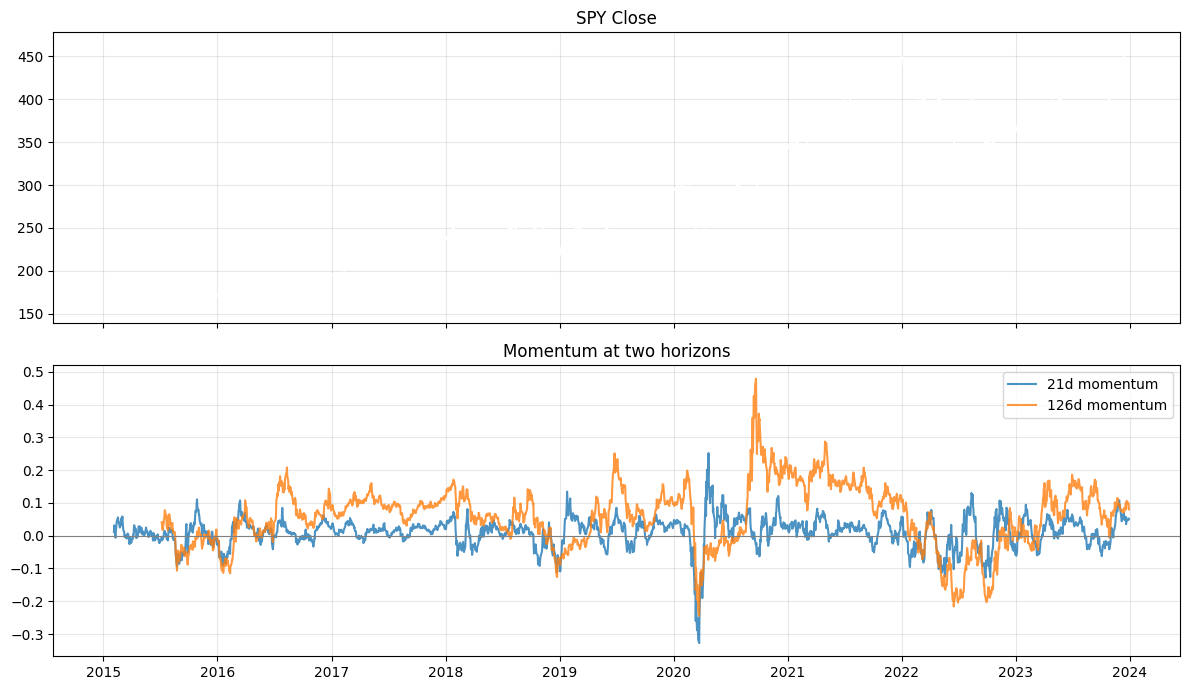

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(spy.index, spy["close"], color="white", lw=1)
ax[0].set_title("SPY Close")

ax[1].plot(spy.index, spy["mom_21d"], label="21d momentum", alpha=0.8)
ax[1].plot(spy.index, spy["mom_126d"], label="126d momentum", alpha=0.8)
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_title("Momentum at two horizons")
ax[1].legend()
plt.tight_layout()
plt.show()


### 4.2 Volatility

Volatility is the single most important regime signal in practice — crisis periods are defined far more reliably by *volatility spikes* than by direction. The standard estimator is the rolling standard deviation of returns, annualized:

$$\sigma_N(t) = \text{std}(r_{t-N:t}) \times \sqrt{252}$$

Note: this uses *close-to-close* returns. More sophisticated estimators (Parkinson, Garman-Klass) use intraday high/low, which is more data-efficient — worth exploring once you've nailed the basics, but realized volatility from close prices is a perfectly good starting feature.


Price        log_ret    vol_5d   vol_21d   vol_63d
Ticker                                            
Date                                              
2023-12-19  0.006062  0.088312  0.071799  0.126076
2023-12-20 -0.013954  0.131819  0.089670  0.124611
2023-12-21  0.009437  0.148205  0.092425  0.125423
2023-12-22  0.002008  0.146192  0.092227  0.125311
2023-12-26  0.004214  0.144243  0.092338  0.120942
2023-12-27  0.001807  0.138928  0.091169  0.120908
2023-12-28  0.000378  0.056450  0.091317  0.120675
2023-12-29 -0.002899  0.041647  0.092570  0.120745


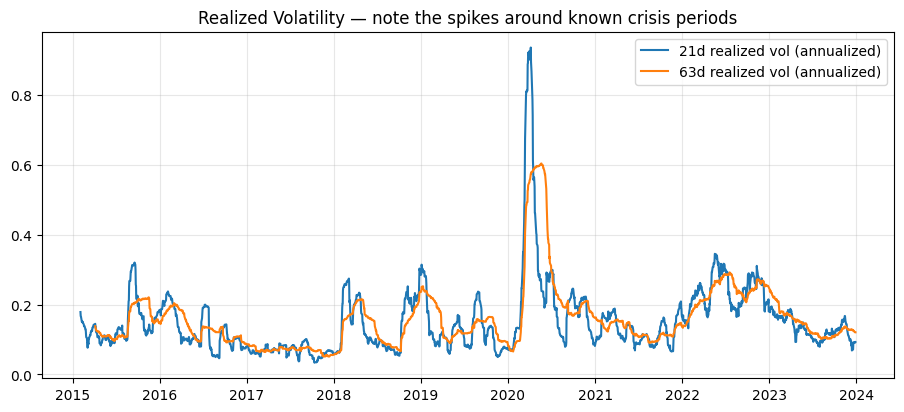

In [45]:
# --- Realized volatility at multiple horizons ---
for window in [5, 21, 63]:
    spy[f"vol_{window}d"] = spy["log_ret"].rolling(window).std() * np.sqrt(252)

print(spy[["log_ret", "vol_5d", "vol_21d", "vol_63d"]].tail(8))

fig, ax = plt.subplots()
ax.plot(spy.index, spy["vol_21d"], label="21d realized vol (annualized)")
ax.plot(spy.index, spy["vol_63d"], label="63d realized vol (annualized)")
ax.set_title("Realized Volatility — note the spikes around known crisis periods")
ax.legend()
plt.show()


### 4.3 Rolling vs Expanding Windows — and why the choice matters

This distinction is easy to gloss over but it shouldn't be as it directly determines what kind of bias you might introduce.

- **`.rolling(N)`** — a fixed-size window that slides forward. At any time `t` it only sees the last `N` observations. This is what you want for *regime-sensitive* features: volatility 5 years ago tells you nothing about whether today is calm or stressed.
- **`.expanding()`** — a window that starts at the beginning of your data and grows by one observation each step. Useful for things like "all-time average return up to today" or — critically — **for normalization statistics in walk-forward validation**, where you only want to use information available up to time `t`, using *all* of it, not just a fixed recent slice.

The trap: if you compute a feature using `.mean()` or `.std()` over the **entire dataset** (not rolling, not expanding-up-to-t) you've used future information to describe the past. That's lookahead bias, and Section 7 deals with it directly.


   value  rolling_mean_3  expanding_mean
0     10             NaN             NaN
1     12             NaN             NaN
2      9       10.333333       10.333333
3     15       12.000000       11.500000
4     20       14.666667       13.200000
5     18       17.666667       14.000000
6     14       17.333333       14.000000
7     22       18.000000       15.000000
8     19       18.333333       15.444444
9     25       22.000000       16.400000


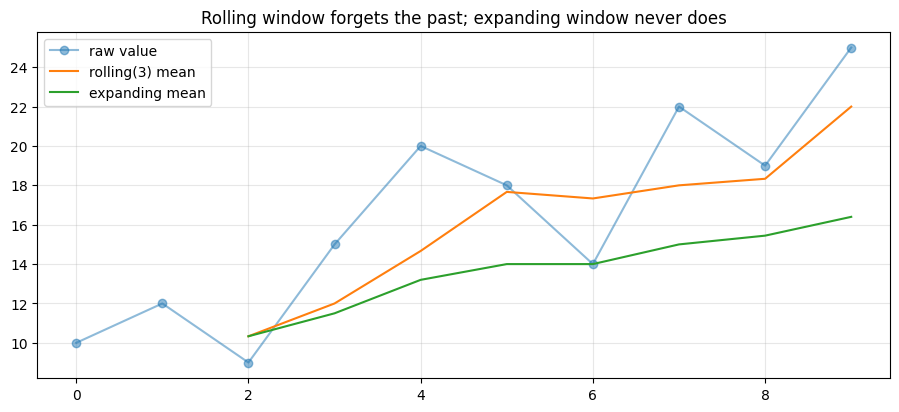

In [46]:
# --- Rolling vs expanding, side by side ---
toy = pd.Series([10, 12, 9, 15, 20, 18, 14, 22, 19, 25], name="value")

rolling_mean = toy.rolling(window=3).mean()
expanding_mean = toy.expanding(min_periods=3).mean()

comparison = pd.DataFrame({
    "value": toy,
    "rolling_mean_3": rolling_mean,
    "expanding_mean": expanding_mean,
})
print(comparison)

fig, ax = plt.subplots()
ax.plot(toy.index, toy, "o-", label="raw value", alpha=0.5)
ax.plot(toy.index, rolling_mean, label="rolling(3) mean")
ax.plot(toy.index, expanding_mean, label="expanding mean")
ax.legend()
ax.set_title("Rolling window forgets the past; expanding window never does")
plt.show()


### 4.4 Z-scoring features (and doing it correctly)

HMMs and most ML models are sensitive to feature scale for e.g. a volatility feature ranging 0.05–0.6 and a momentum feature ranging -0.3–0.3 need to be put on comparable scales, typically via z-scoring:

$$z_t = \frac{x_t - \mu}{\sigma}$$

**The trap, again:** if you compute `mu` and `sigma` using the full dataset's mean/std, you've leaked future information into every single row including the earliest ones. The correct approach in a walk-forward setting is to compute `mu`/`sigma` only from training data, or use an expanding/rolling window so that the z-score at time `t` only reflects information available *up to* `t`. We'll make this concrete in Section 7-8.


In [47]:
# WRONG - uses the entire series' stats, leaking the future into the past
spy["vol_21d_zscore_LEAKY"] = (
    (spy["vol_21d"] - spy["vol_21d"].mean()) / spy["vol_21d"].std()
)

# BETTER - expanding window, so z-score at time t only uses data up to t
roll_mean = spy["vol_21d"].expanding(min_periods=63).mean()
roll_std = spy["vol_21d"].expanding(min_periods=63).std()
spy["vol_21d_zscore_SAFE"] = (spy["vol_21d"] - roll_mean) / roll_std

print(spy[["vol_21d", "vol_21d_zscore_LEAKY", "vol_21d_zscore_SAFE"]].dropna().head(8))


Price        vol_21d vol_21d_zscore_LEAKY vol_21d_zscore_SAFE
Ticker                                                       
Date                                                         
2015-05-04  0.090832            -0.589515           -1.286610
2015-05-05  0.098318            -0.516463           -0.955781
2015-05-06  0.098996            -0.509848           -0.913963
2015-05-07  0.099266            -0.507208           -0.890195
2015-05-08  0.108049            -0.421500           -0.513103
2015-05-11  0.108101            -0.420995           -0.506196
2015-05-12  0.107394            -0.427889           -0.531506
2015-05-13  0.107215            -0.429644           -0.534319


### Try it
1. Build a momentum feature at a horizon of your choice (try 10 days) AND a volatility feature at the same horizon.
2. Plot both on twin axes (`ax2 = ax.twinx()`) to visually inspect: do volatility spikes tend to coincide with negative momentum? (This is the kind of inspection that justifies feeding both into the HMM as separate but related signals.)
3. Z-score your momentum feature using an **expanding** window with `min_periods=63`, and explain in a markdown cell why `min_periods` matters here (hint: what happens to a z-score computed from only 2 data points?).


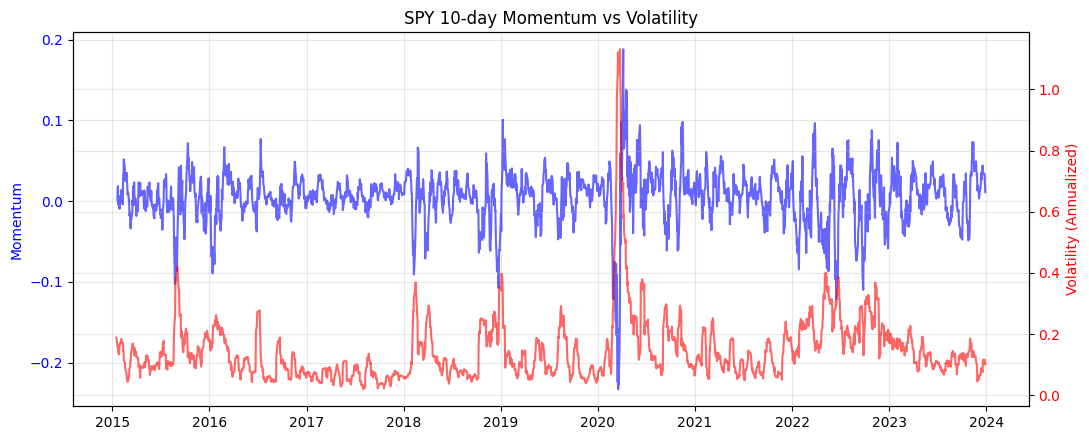

Price        mom_10d mom_10d_zscore
Ticker                             
Date                               
2015-04-20  0.009720       0.190709
2015-04-21  0.011193       0.272433
2015-04-22  0.012742       0.358286
2015-04-23  0.010819       0.245109
2015-04-24  0.007665       0.060906


In [48]:
spy_feat = spy.copy()
spy_feat["mom_10d"] = spy_feat["close"].pct_change(10)
spy_feat["vol_10d"] = spy_feat["log_ret"].rolling(10).std() * np.sqrt(252)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(spy_feat.index, spy_feat["mom_10d"], color="blue", label="10d Momentum", alpha=0.6)
ax1.set_ylabel("Momentum", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(spy_feat.index, spy_feat["vol_10d"], color="red", label="10d Volatility", alpha=0.6)
ax2.set_ylabel("Volatility (Annualized)", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("SPY 10-day Momentum vs Volatility")
plt.tight_layout()
plt.show()

# Z-score momentum using expanding window
roll_m = spy_feat["mom_10d"].expanding(min_periods=63).mean()
roll_s = spy_feat["mom_10d"].expanding(min_periods=63).std()
spy_feat["mom_10d_zscore"] = (spy_feat["mom_10d"] - roll_m) / roll_s
print(spy_feat[["mom_10d", "mom_10d_zscore"]].dropna().head())


### Why `min_periods` matters for Z-scoring features

The `min_periods` parameter specifies the minimum number of observations required to calculate the statistic (mean/standard deviation) for the window. If we set `min_periods` to a very small number (like 2 or 3), the z-score computed in the early part of the time series will be extremely unstable and noisy. For example, a standard deviation computed from only 2 data points is highly volatile, which leads to massive spikes in the z-score. By enforcing `min_periods=63` (approx. 3 months of trading days), we ensure that the normalization parameters (mean and volatility) are calculated over a statistically robust sample size, avoiding initial noisy spikes.

---
## 5. Matplotlib —

You will produce three kinds of plots constantly in this project: price/return time series, regime-overlay charts (price colored by hidden state), and backtest equity curves with drawdown shading. Matplotlib does all three without needing anything fancier.


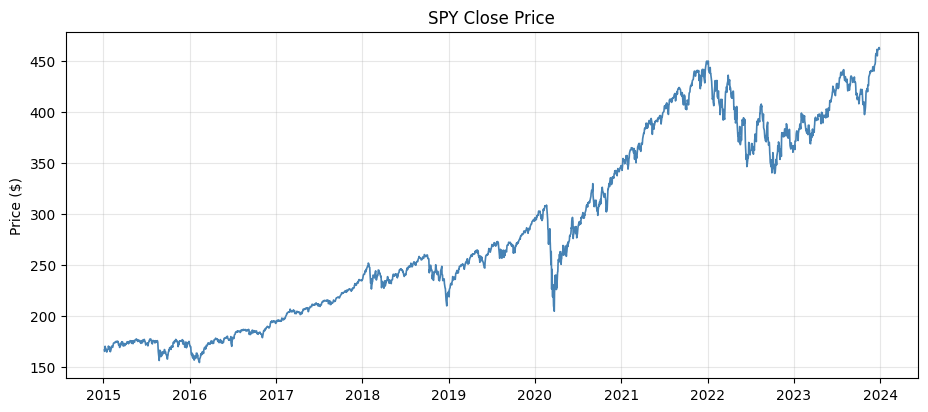

In [49]:
# --- Basic time series plot with proper date formatting ---
fig, ax = plt.subplots()
ax.plot(spy.index, spy["close"], color="steelblue", lw=1.2)
ax.set_title("SPY Close Price")
ax.set_ylabel("Price ($)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()


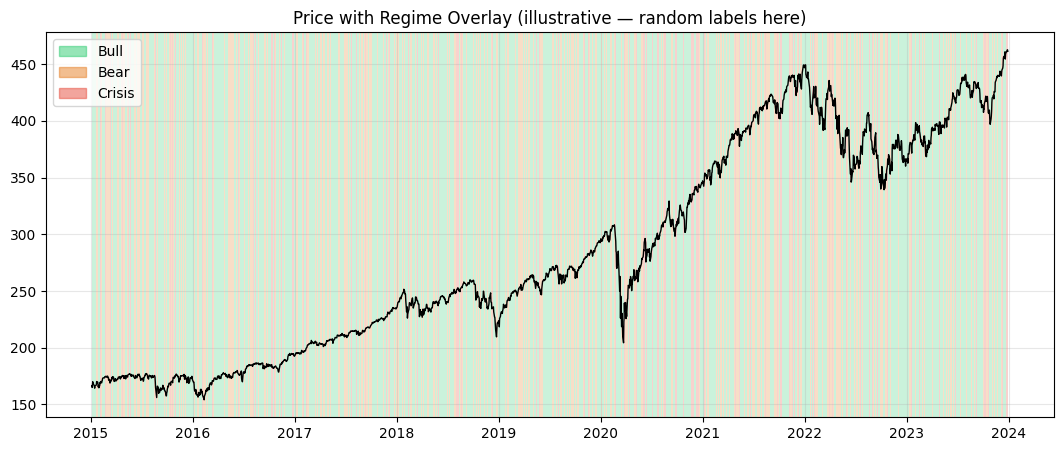

In [50]:
# --- Regime overlay using axvspan ---

# fake regime labels for demonstration: 0=Bull, 1=Bear, 2=Crisis
np.random.seed(1)
fake_regime = np.random.choice([0, 1, 2], size=len(spy), p=[0.6, 0.3, 0.1])
spy["fake_regime"] = fake_regime

regime_colors = {0: "#2ecc71", 1: "#e67e22", 2: "#e74c3c"}
regime_names = {0: "Bull", 1: "Bear", 2: "Crisis"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spy.index, spy["close"], color="black", lw=1, zorder=3)

# shade contiguous blocks of the same regime
regime_vals = spy["fake_regime"].values
start_idx = 0
for i in range(1, len(regime_vals) + 1):
    if i == len(regime_vals) or regime_vals[i] != regime_vals[start_idx]:
        ax.axvspan(spy.index[start_idx], spy.index[min(i, len(regime_vals)-1)],
                   color=regime_colors[regime_vals[start_idx]], alpha=0.25, lw=0)
        start_idx = i

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.5) for c in regime_colors.values()]
ax.legend(handles, regime_names.values(), loc="upper left")
ax.set_title("Price with Regime Overlay (illustrative — random labels here)")
plt.show()


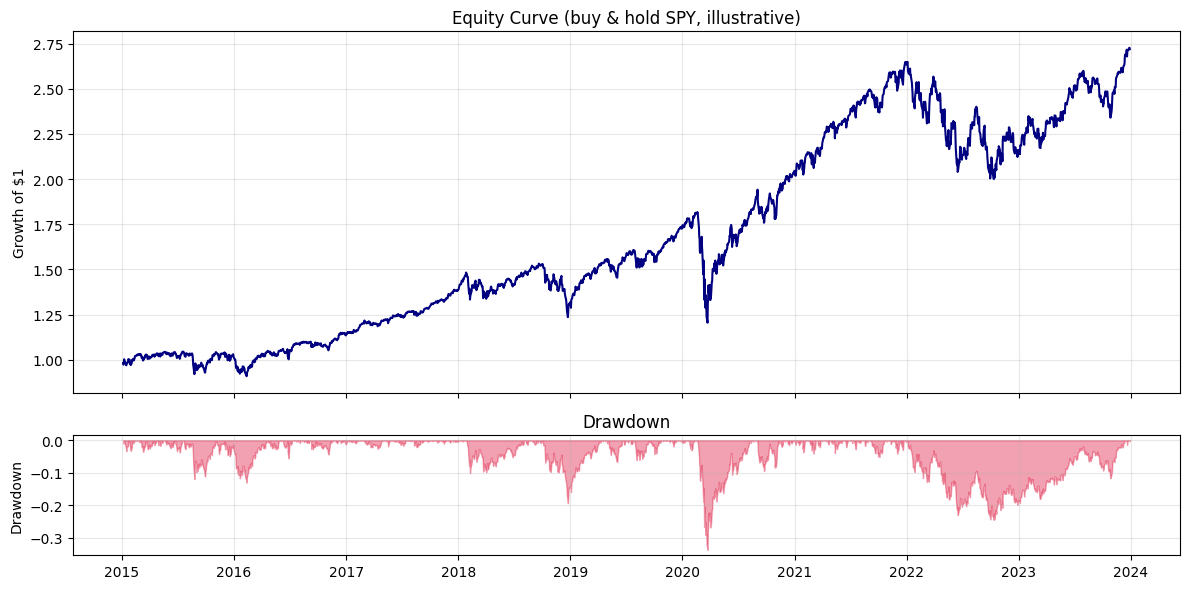

In [51]:
# --- Equity curve with drawdown subplot (your tear sheet needs this) ---
strategy_returns = spy["log_ret"].fillna(0)
equity_curve = np.exp(strategy_returns.cumsum())
running_max = equity_curve.cummax()
drawdown = equity_curve / running_max - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(equity_curve.index, equity_curve, color="navy")
axes[0].set_title("Equity Curve (buy & hold SPY, illustrative)")
axes[0].set_ylabel("Growth of $1")

axes[1].fill_between(drawdown.index, drawdown, 0, color="crimson", alpha=0.4)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.show()


### Try it
Recreate the regime-overlay plot above but instead of random fake labels, define a simple **rule-based** "regime": label a day Crisis if `vol_21d_zscore_SAFE > 1.5`, Bear if `mom_21d < 0` (and not Crisis), else Bull. This is a hand-coded baseline regime classifier — useful to have before you trust the HMM's output, since you'll want something to sanity-check it against.


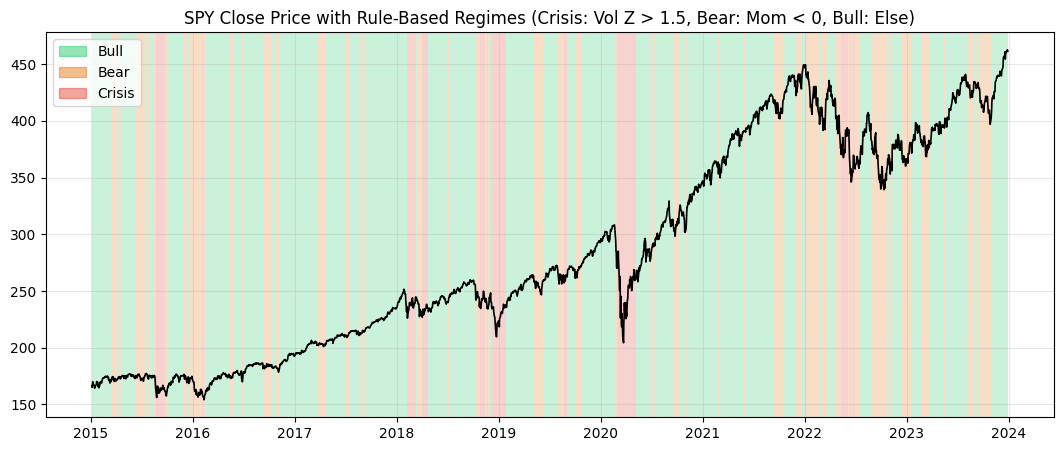

In [52]:
# Matplotlib Exercise - Rule-Based Regime Shading
spy_feat = spy.copy()

# 1. Rule-based regime definition:
# Label a day Crisis if vol_21d_zscore_SAFE > 1.5
# Bear if mom_21d < 0 (and not Crisis)
# Bull: else
roll_m_v = spy_feat["vol_21d"].expanding(min_periods=63).mean()
roll_s_v = spy_feat["vol_21d"].expanding(min_periods=63).std()
spy_feat["vol_21d_zscore_SAFE"] = (spy_feat["vol_21d"] - roll_m_v) / roll_s_v

spy_feat["rule_regime"] = 0  # default to Bull
spy_feat.loc[spy_feat["mom_21d"] < 0, "rule_regime"] = 1  # Bear
spy_feat.loc[spy_feat["vol_21d_zscore_SAFE"] > 1.5, "rule_regime"] = 2  # Crisis

# 2. Recreate the regime-overlay plot using rule-based regimes
regime_colors = {0: "#2ecc71", 1: "#e67e22", 2: "#e74c3c"}  # Green = Bull, Orange = Bear, Red = Crisis
regime_names = {0: "Bull", 1: "Bear", 2: "Crisis"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spy_feat.index, spy_feat["close"], color="black", lw=1.2, zorder=3)

# Shade contiguous blocks of the same regime
regime_vals = spy_feat["rule_regime"].values
start_idx = 0
for i in range(1, len(regime_vals) + 1):
    if i == len(regime_vals) or regime_vals[i] != regime_vals[start_idx]:
        ax.axvspan(spy_feat.index[start_idx], spy_feat.index[min(i, len(regime_vals)-1)],
                   color=regime_colors[regime_vals[start_idx]], alpha=0.25, lw=0)
        start_idx = i

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.5) for c in regime_colors.values()]
ax.legend(handles, regime_names.values(), loc="upper left")
ax.set_title("SPY Close Price with Rule-Based Regimes (Crisis: Vol Z > 1.5, Bear: Mom < 0, Bull: Else)")
plt.show()


---
## 6. yfinance

Your data sources list includes Yahoo Finance for multi-asset daily returns, FRED for macro indicators, and CBOE for VIX history. `yfinance` is your main workhorse for the first and last of those (VIX is available on Yahoo as the ticker `^VIX`). This section covers the patterns you'll reuse constantly: multi-ticker downloads, handling the MultiIndex columns yfinance returns, and aligning everything onto one clean DataFrame.


In [53]:
# --- Downloading multiple tickers at once ---
tickers = ["SPY", "TLT", "GLD", "^VIX"]   # equities, bonds, gold, vol index
raw = yf.download(tickers, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)

print(raw.columns)   # MultiIndex: (field, ticker)
print(raw.head())


MultiIndex([( 'Close',  'GLD'),
            ( 'Close',  'SPY'),
            ( 'Close',  'TLT'),
            ( 'Close', '^VIX'),
            (  'High',  'GLD'),
            (  'High',  'SPY'),
            (  'High',  'TLT'),
            (  'High', '^VIX'),
            (   'Low',  'GLD'),
            (   'Low',  'SPY'),
            (   'Low',  'TLT'),
            (   'Low', '^VIX'),
            (  'Open',  'GLD'),
            (  'Open',  'SPY'),
            (  'Open',  'TLT'),
            (  'Open', '^VIX'),
            ('Volume',  'GLD'),
            ('Volume',  'SPY'),
            ('Volume',  'TLT'),
            ('Volume', '^VIX')],
           names=['Price', 'Ticker'])
Price            Close                                          High                                           Low  \
Ticker             GLD         SPY        TLT       ^VIX         GLD         SPY        TLT       ^VIX         GLD   
Date                                                                                 

In [54]:
# --- Extracting just Close prices cleanly ---
close_prices = raw["Close"].copy()
close_prices.columns.name = None
close_prices = close_prices.rename(columns={"^VIX": "VIX"})
print(close_prices.head())
print("\nMissing values per column:\n", close_prices.isna().sum())


                   GLD         SPY        TLT        VIX
Date                                                    
2015-01-02  114.080002  169.687866  93.023689  17.790001
2015-01-05  115.800003  166.623367  94.485001  19.920000
2015-01-06  117.120003  165.053909  96.187347  21.120001
2015-01-07  116.430000  167.110626  95.997421  19.309999
2015-01-08  115.940002  170.076035  94.726128  17.010000

Missing values per column:
 GLD    0
SPY    0
TLT    0
VIX    0
dtype: int64


In [26]:
# --- Building your multi-asset returns matrix (the actual input to the HMM) ---
asset_prices = close_prices[["SPY", "TLT", "GLD"]]
asset_returns = np.log(asset_prices).diff().dropna()

vix_level = close_prices["VIX"]   # VIX is a LEVEL (an index value), not something you return-transform

# Align everything onto the SAME index — inner join drops any dates where one series is missing
master_df = asset_returns.join(vix_level, how="inner").dropna()
print(master_df.head())
print(f"\nFinal aligned dataset: {master_df.shape[0]} rows, {master_df.shape[1]} columns")


                 SPY       TLT       GLD        VIX
Date                                               
2015-01-05 -0.018225  0.015587  0.014965  19.920000
2015-01-06 -0.009464  0.017857  0.011334  21.120001
2015-01-07  0.012384 -0.001976 -0.005909  19.309999
2015-01-08  0.017590 -0.013331 -0.004217  17.010000
2015-01-09 -0.008046  0.010893  0.011321  17.549999

Final aligned dataset: 2263 rows, 4 columns


**A note on `auto_adjust`:** keep it `True` (default in recent yfinance) so prices are adjusted for dividends/splits — using unadjusted close prices for returns will inject fake jumps around dividend dates and split events, which is its own subtle bias.

**A note on missing data:** different exchanges have different holiday calendars, and tickers can have gaps for entirely mundane reasons (delisting, data vendor issues). Always inspect `.isna().sum()` after a join before moving on — silently propagating NaNs into an HMM `.fit()` call will either crash or, worse, silently degrade the fit.


### Try it
1. Download 4 different tickers of your choice covering at least equities + bonds + one alternative asset (commodities, REITs, crypto proxy like `^VIX`-adjacent assets).
2. Build the aligned log-returns DataFrame using the inner-join pattern above.
3. Plot the cumulative return (`np.exp(returns.cumsum())`) of all assets on one chart to visually compare regimes each asset went through (note: 2020 and 2022 should look very different across asset classes).


Missing values per column:
 Ticker
AAPL       0
BTC-USD    0
DBC        0
IEF        0
dtype: int64


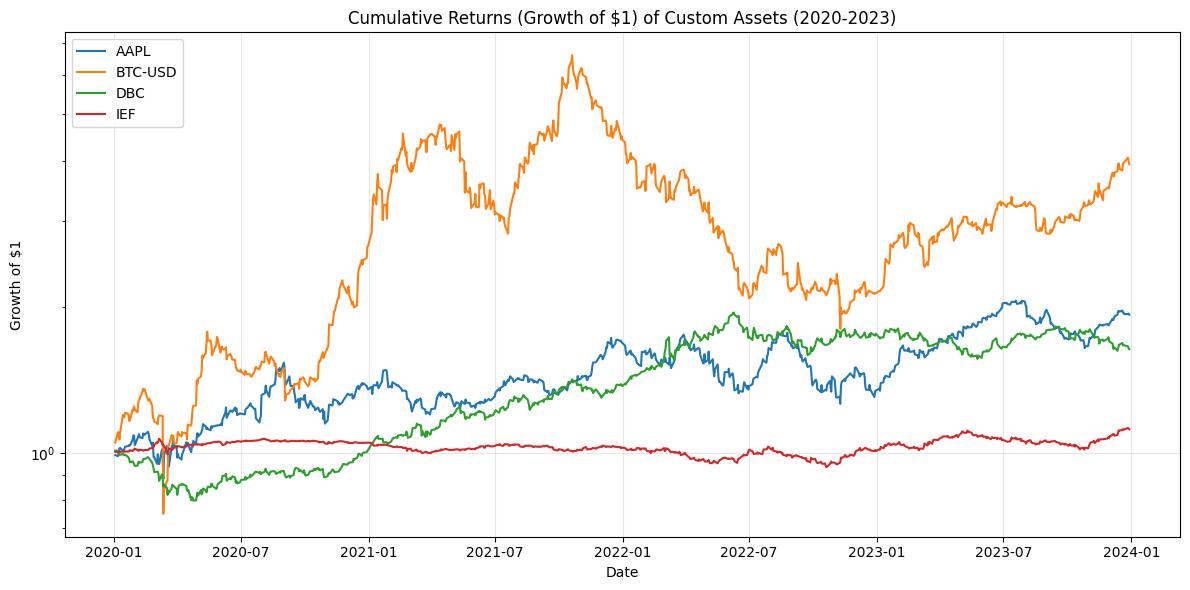

In [55]:
# yfinance Exercise - Multi-Asset Downloads & Returns
# 1. Download 4 different tickers covering equities, bonds, commodities, crypto
my_tickers = ["AAPL", "IEF", "DBC", "BTC-USD"]
raw_my = yf.download(my_tickers, start="2020-01-01", end="2024-01-01", progress=False, auto_adjust=True)

# 2. Extract Close prices and calculate log returns
close_my = raw_my["Close"].copy()
returns_my = np.log(close_my).diff().dropna()
print("Missing values per column:\n", returns_my.isna().sum())

# 3. Plot cumulative returns (growth of $1)
cum_returns = np.exp(returns_my.cumsum())

fig, ax = plt.subplots(figsize=(12, 6))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], label=col, lw=1.5)
ax.set_title("Cumulative Returns (Growth of $1) of Custom Assets (2020-2023)")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.yscale("log")  # log scale for high crypto growth
plt.tight_layout()
plt.show()


---
## 7. The Lookahead Bias Problem (and Why It Kills Backtests)

This is the single most important concept in the whole notebook even more important than any library. Read this section slowly.

### What it is

**Lookahead bias** (also called "future leakage") happens whenever information that would not actually have been available at decision-time `t` is used in a computation that informs the decision at `t`. The model ends up implicitly "knowing the future," and your backtest reports performance that is structurally impossible to achieve in live trading.

It is dangerous specifically because it is **invisible in the backtest results** that is a leaky backtest doesn't crash or throw an error. It just produces results that look *great*, often suspiciously great. Many published "alpha" strategies are actually just well-disguised lookahead bias.

### Where it sneaks into THIS project specifically

| Source | The leak |
|---|---|
| Feature normalization | Z-scoring with full-sample mean/std (Section 4.4) |
| HMM fitting | Fitting the HMM once on the entire dataset, then "predicting" regimes for early dates — the model has seen the whole future distribution of states before labeling day 1 |
| Regime smoothing | Using a centered rolling window (e.g. `.rolling(5, center=True)`) to "denoise" regime labels — center=True uses future observations |
| Data revisions | Macro data like GDP/CPI gets *revised* after initial release; using the final revised value as of the analysis date (rather than the value that was actually known at the time) is a subtle but real leak |
| Survivorship | Using today's S&P 500 constituent list to backtest 2008 — stocks that got delisted/bankrupt are invisible, flattering the results |
| Train/test splits | Randomly shuffling time series rows into train/test sets — adjacent days are correlated, so a "future" day ends up in the training set teaching the model about a "past" day's test outcome |

### A concrete, runnable example of the bug


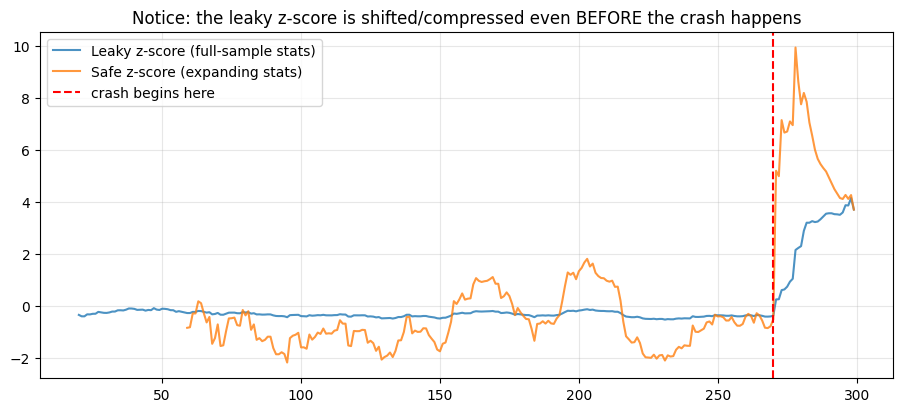

Leaky z-score mean (first 100 obs, pre-crash): -0.239
Safe z-score mean (first 100 obs, pre-crash):  -0.9411


In [56]:
# Demonstrating the z-score leak concretely with a toy "crash"
np.random.seed(7)
n = 300
calm = np.random.normal(0.0005, 0.006, n - 30)
crash = np.random.normal(-0.01, 0.04, 30)   # a violent regime at the END of the sample
toy_returns = pd.Series(np.concatenate([calm, crash]))

toy_vol = toy_returns.rolling(21).std() * np.sqrt(252)

# LEAKY: full-sample stats are influenced by the crash, even for EARLY observations
leaky_z = (toy_vol - toy_vol.mean()) / toy_vol.std()

# CORRECT: expanding stats only see what existed up to that point in time
safe_mean = toy_vol.expanding(min_periods=40).mean()
safe_std = toy_vol.expanding(min_periods=40).std()
safe_z = (toy_vol - safe_mean) / safe_std

fig, ax = plt.subplots()
ax.plot(leaky_z, label="Leaky z-score (full-sample stats)", alpha=0.8)
ax.plot(safe_z, label="Safe z-score (expanding stats)", alpha=0.8)
ax.axvline(n - 30, color="red", ls="--", label="crash begins here")
ax.legend()
ax.set_title("Notice: the leaky z-score is shifted/compressed even BEFORE the crash happens")
plt.show()

print("Leaky z-score mean (first 100 obs, pre-crash):", round(leaky_z.iloc[:100].mean(), 4))
print("Safe z-score mean (first 100 obs, pre-crash): ", round(safe_z.iloc[:100].mean(), 4))


Notice the leaky series is systematically distorted in the *pre-crash* period purely because a crash exists *later* in the dataset that the "leaky" calculation already knows about. A model trained on the leaky feature would, in effect, have advance warning that volatility eventually spikes — something it could never know in live trading.

### The fix, as a principle

> **At every point in time `t`, every number in your dataset must be computable using only information dated `≤ t`.**

This single sentence is the entire content of Section 8 (Walk-Forward Validation), just operationalized as a concrete training procedure.


---
## 8. Walk-Forward Validation — Train/Test Splits That Respect Time

Standard k-fold cross-validation (randomly splitting data into folds) is **wrong** for time series. It violates the principle from Section 7 because random folds let "future" data train a model that's tested on "past" data. Walk-forward validation is the time-series-correct alternative, and it's explicitly listed as a project goal ("Build a Walk-Forward Validation Harness").

### The core idea

Instead of one random split, you create a *sequence* of train/test splits that all slide forward in time:

```
Fold 1: train [████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░] test [░░░░████░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
Fold 2: train [████████████░░░░░░░░░░░░░░░░░░░░░░░░] test [░░░░░░░░░░░░████░░░░░░░░░░░░░░░░░░░░]
Fold 3: train [████████████████░░░░░░░░░░░░░░░░░░░░] test [░░░░░░░░░░░░░░░░░░░░████░░░░░░░░░░░░]
...
```

Each fold: fit ONLY on the training window, evaluate ONLY on the test window immediately after it, then slide both windows forward. Two flavors:

- **Expanding window**: training set grows each fold (always starts at the same point, end moves forward). Uses all available history each time — good when you believe more data always helps.
- **Rolling window**: training set is a fixed size that slides forward (both start and end move). Good when older data may reflect an obsolete regime and could actively hurt the fit ("regime drift").

For an HMM specifically, **re-fit the HMM separately within each fold**, using only that fold's training data. Never fit the HMM once on the full dataset and then split — that's the exact leak from Section 7.


In [57]:
def expanding_walk_forward_splits(n_obs, n_splits=5, min_train_size=252, test_size=63):
    """
    Yields (train_idx, test_idx) tuples for expanding-window walk-forward validation.

    n_obs:          total number of observations
    n_splits:       how many train/test folds to produce
    min_train_size: minimum size of the first training window (in observations)
    test_size:      size of each test window
    """
    splits = []
    start_test = min_train_size
    for i in range(n_splits):
        train_idx = np.arange(0, start_test)
        test_idx = np.arange(start_test, min(start_test + test_size, n_obs))
        if len(test_idx) == 0:
            break
        splits.append((train_idx, test_idx))
        start_test += test_size
    return splits


# Demonstration
n_obs = len(spy)
splits = expanding_walk_forward_splits(n_obs, n_splits=6, min_train_size=500, test_size=126)

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"Fold {i+1}: train = obs[{train_idx[0]}:{train_idx[-1]}]  "
          f"({spy.index[train_idx[0]].date()} to {spy.index[train_idx[-1]].date()})  |  "
          f"test = obs[{test_idx[0]}:{test_idx[-1]}]  "
          f"({spy.index[test_idx[0]].date()} to {spy.index[test_idx[-1]].date()})")


Fold 1: train = obs[0:499]  (2015-01-05 to 2016-12-27)  |  test = obs[500:625]  (2016-12-28 to 2017-06-28)
Fold 2: train = obs[0:625]  (2015-01-05 to 2017-06-28)  |  test = obs[626:751]  (2017-06-29 to 2017-12-27)
Fold 3: train = obs[0:751]  (2015-01-05 to 2017-12-27)  |  test = obs[752:877]  (2017-12-28 to 2018-06-28)
Fold 4: train = obs[0:877]  (2015-01-05 to 2018-06-28)  |  test = obs[878:1003]  (2018-06-29 to 2018-12-28)
Fold 5: train = obs[0:1003]  (2015-01-05 to 2018-12-28)  |  test = obs[1004:1129]  (2018-12-31 to 2019-07-01)
Fold 6: train = obs[0:1129]  (2015-01-05 to 2019-07-01)  |  test = obs[1130:1255]  (2019-07-02 to 2019-12-30)


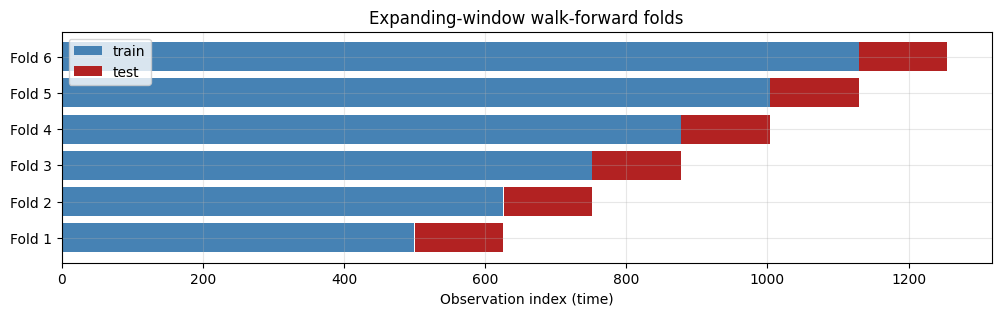

In [58]:
# Visualize the fold structure
fig, ax = plt.subplots(figsize=(12, 3))
for i, (train_idx, test_idx) in enumerate(splits):
    ax.barh(i, train_idx[-1] - train_idx[0], left=train_idx[0], color="steelblue", label="train" if i == 0 else "")
    ax.barh(i, test_idx[-1] - test_idx[0], left=test_idx[0], color="firebrick", label="test" if i == 0 else "")
ax.set_yticks(range(len(splits)))
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(splits))])
ax.set_xlabel("Observation index (time)")
ax.set_title("Expanding-window walk-forward folds")
ax.legend(loc="upper left")
plt.show()


### Why re-fitting matters: a sketch of the correct loop

```python
for train_idx, test_idx in splits:
    train_data = features.iloc[train_idx]
    test_data  = features.iloc[test_idx]

    # 1. Compute normalization stats ONLY on train_data
    mu, sigma = train_data.mean(), train_data.std()
    train_scaled = (train_data - mu) / sigma
    test_scaled  = (test_data  - mu) / sigma   # test uses TRAIN's mu/sigma, never its own

    # 2. Fit the HMM ONLY on train_scaled
    model = hmm.GaussianHMM(n_components=3, covariance_type="full")
    model.fit(train_scaled)

    # 3. Predict regimes on test_scaled using the ALREADY-FITTED model
    test_regimes = model.predict(test_scaled)

    # 4. Evaluate strategy performance on test_idx ONLY, using test_regimes
    #    ... (apply your dynamic constraint mapping here, compute Sharpe etc.)
```

Notice step 1: the test set is transformed using statistics learned **only** from the training set. This is the time-series-correct analogue of `sklearn`'s `scaler.fit(X_train)` then `scaler.transform(X_test)` pattern — same principle, just made explicit because `hmmlearn` doesn't enforce it for you.


### Try it
Using the `expanding_walk_forward_splits` function above, write a loop that, for each fold, computes the **training-set-only** mean and std of `mom_21d` and `vol_21d`, applies that to z-score both train and test slices, and prints the resulting test-set z-score range for each fold. Confirm the train-derived stats don't perfectly match what you'd get from a full-sample z-score (this is your "I actually avoided the leak" check).


In [59]:
# Walk-Forward Validation Exercise - Avoid Lookahead Bias
full_mean = spy[["mom_21d", "vol_21d"]].mean()
full_std = spy[["mom_21d", "vol_21d"]].std()

for idx, (train_idx, test_idx) in enumerate(splits):
    train_data = spy[["mom_21d", "vol_21d"]].iloc[train_idx]
    test_data = spy[["mom_21d", "vol_21d"]].iloc[test_idx]

    # Compute training stats only
    mean_train = train_data.mean()
    std_train = train_data.std()

    # Scale test slice using train stats (safe)
    test_scaled_safe = (test_data - mean_train) / std_train

    # Scale test slice using full-sample stats (leaky)
    test_scaled_leaky = (test_data - full_mean) / full_std

    print(f"Fold {idx+1}:")
    print(f"  Test Vol Z-Score Range (Safe):  [{test_scaled_safe['vol_21d'].min():.4f}, {test_scaled_safe['vol_21d'].max():.4f}]")
    print(f"  Test Vol Z-Score Range (Leaky): [{test_scaled_leaky['vol_21d'].min():.4f}, {test_scaled_leaky['vol_21d'].max():.4f}]")
    print(f"  Max Absolute Difference (Vol):  {np.max(np.abs(test_scaled_safe['vol_21d'] - test_scaled_leaky['vol_21d'])):.4f}\n")


Fold 1:
  Test Vol Z-Score Range (Safe):  [-1.5446, -0.8077]
  Test Vol Z-Score Range (Leaky): [-1.0054, -0.6070]
  Max Absolute Difference (Vol):  0.5392

Fold 2:
  Test Vol Z-Score Range (Safe):  [-1.5491, -0.3428]
  Test Vol Z-Score Range (Leaky): [-1.1426, -0.4857]
  Max Absolute Difference (Vol):  0.4065

Fold 3:
  Test Vol Z-Score Range (Safe):  [-0.9503, 2.9510]
  Test Vol Z-Score Range (Leaky): [-0.9079, 1.2055]
  Max Absolute Difference (Vol):  1.7455

Fold 4:
  Test Vol Z-Score Range (Safe):  [-1.0590, 3.1421]
  Test Vol Z-Score Range (Leaky): [-0.9518, 1.4846]
  Max Absolute Difference (Vol):  1.6575

Fold 5:
  Test Vol Z-Score Range (Safe):  [-0.9772, 3.1842]
  Test Vol Z-Score Range (Leaky): [-0.9016, 1.5940]
  Max Absolute Difference (Vol):  1.5902

Fold 6:
  Test Vol Z-Score Range (Safe):  [-1.1444, 1.8632]
  Test Vol Z-Score Range (Leaky): [-0.9887, 0.8411]
  Max Absolute Difference (Vol):  1.0221



---
## 9. ML Primer - From Hidden Markov Models to PyTorch

The capstone's core model is a **Hidden Markov Model (HMM)**, broader tech stack implies you should be comfortable with the ML ecosystem beyond just `hmmlearn` hence the PyTorch primer at the end of this section, useful if you extend the project (e.g. a neural regime classifier, or an LSTM-based feature extractor).

### 9.1 What an HMM actually models

An HMM assumes there's a **hidden state** (the market regime - Bull/Bear/Crisis) that you can't observe directly, but which generates **observable** data (your returns, volatility, momentum features) according to state-specific probability distributions. Two pieces:

- **Transition matrix** — probability of moving from one hidden state to another between consecutive time steps. This encodes regime *persistence* (in practice, regimes are usually "sticky" — the diagonal of this matrix tends to be high).
- **Emission distributions** — for each hidden state, a probability distribution (typically Gaussian, possibly multivariate) over what the observed features look like *given* you're in that state.

Fitting an HMM means estimating both pieces from data using the **Baum-Welch algorithm** (an EM-style procedure) — `hmmlearn` does this for you via `.fit()`. Once fit, the **Viterbi algorithm** finds the single most likely *sequence* of hidden states given the observed data — this is what `.predict()` calls under the hood, and it's distinct from just picking the most-likely-state-at-each-timestep independently (Viterbi accounts for transition probabilities across the whole sequence, not just one timestep at a time).


In [60]:
if HMM_OK:
    from hmmlearn import hmm

    # Build a small, clean feature set for demonstration
    feat_df = spy[["log_ret", "vol_21d"]].dropna().copy()
    feat_df["mom_21d"] = spy["mom_21d"]
    feat_df = feat_df.dropna()

    X = feat_df[["log_ret", "vol_21d", "mom_21d"]].values

    # NOTE: fitting on the FULL series here is for demonstration of the API only.
    # In the actual project, this fit call must happen INSIDE each walk-forward
    # fold's training data, never on the full dataset (Section 7-8).
    model = hmm.GaussianHMM(n_components=3, covariance_type="diag",
                              n_iter=200, random_state=42)
    model.fit(X)

    hidden_states = model.predict(X)   # this calls Viterbi internally
    feat_df["state"] = hidden_states

    print("Transition matrix:\n", np.round(model.transmat_, 3))
    print("\nMean feature values per state (log_ret, vol_21d, mom_21d):\n",
          np.round(model.means_, 4))
    print("\nState counts:\n", feat_df["state"].value_counts())
else:
    print("Skipping - hmmlearn not installed")


Transition matrix:
 [[0.983 0.002 0.015]
 [0.034 0.966 0.   ]
 [0.011 0.    0.989]]

Mean feature values per state (log_ret, vol_21d, mom_21d):
 [[ 1.000e-04  2.046e-01 -1.500e-03]
 [-1.200e-03  5.545e-01 -5.890e-02]
 [ 8.000e-04  9.400e-02  2.220e-02]]

State counts:
 state
2    1280
0     899
1      63
Name: count, dtype: int64


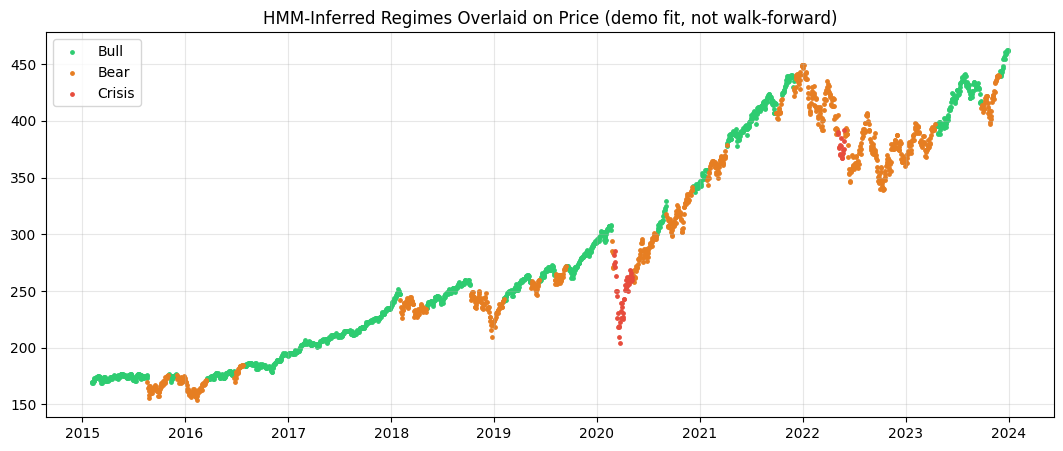

In [61]:
if HMM_OK:
    # Map states to interpretable labels by inspecting their mean volatility
    # (highest avg vol -> Crisis, lowest -> Bull, middle -> Bear). This is a common
    # post-hoc labeling heuristic since HMM state indices (0,1,2) are arbitrary.
    state_vol = feat_df.groupby("state")["vol_21d"].mean().sort_values()
    label_map = {state_vol.index[0]: "Bull", state_vol.index[1]: "Bear", state_vol.index[2]: "Crisis"}
    feat_df["regime_label"] = feat_df["state"].map(label_map)

    fig, ax = plt.subplots(figsize=(13, 5))
    colors = {"Bull": "#2ecc71", "Bear": "#e67e22", "Crisis": "#e74c3c"}
    for label, color in colors.items():
        mask = feat_df["regime_label"] == label
        ax.scatter(feat_df.index[mask], spy.loc[feat_df.index[mask], "close"],
                   s=6, color=color, label=label)
    ax.legend()
    ax.set_title("HMM-Inferred Regimes Overlaid on Price (demo fit, not walk-forward)")
    plt.show()


### 9.2 Why `n_components` and `covariance_type` matter

- `n_components=3` is a modeling *choice*, not something the HMM discovers - it directly corresponds to your project's goal of detecting Bull/Bear/Crisis. Too few states under-discriminates; too many states can produce regimes that aren't economically meaningful (overfitting to noise).
- `covariance_type`: `"diag"` assumes features are uncorrelated within a state (faster, fewer parameters, less overfitting risk with limited data); `"full"` allows feature correlations within a state (more expressive, needs more data to fit reliably). With only a handful of features and a few thousand daily observations, start with `"diag"` or `"tied"` before reaching for `"full"`.

### 9.3 scikit-learn touchpoints

You'll use `scikit-learn` mainly for utilities around the HMM workflow — train/test index management, metrics, and possibly a baseline supervised classifier to sanity-check the HMM against. A few patterns worth knowing:


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# StandardScaler is the sklearn equivalent of manual z-scoring (Section 4.4) -
# same leak risk applies: ALWAYS .fit() on train only, .transform() on test.
scaler = StandardScaler()
# Correct pattern (illustrative, using all data as "train" here for the demo only):
X_scaled = scaler.fit_transform(X)
print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Scaled feature stds (should be ~1): ", X_scaled.std(axis=0).round(4))

# silhouette_score is a generic clustering quality metric you can use as a SECONDARY
# sanity check on your HMM states (treating them like cluster labels) - not a replacement
# for proper walk-forward backtested evaluation, just a diagnostic.
if HMM_OK:
    score = silhouette_score(X_scaled, hidden_states)
    print(f"\nSilhouette score of HMM states (diagnostic only): {score:.3f}")


Scaled feature means (should be ~0): [ 0. -0. -0.]
Scaled feature stds (should be ~1):  [1. 1. 1.]

Silhouette score of HMM states (diagnostic only): 0.269


### 9.4 PyTorch Primer

The core capstone doesn't strictly require PyTorch - `hmmlearn` handles the HMM. But you should be comfortable building and training a small neural net, in case you extend the project (e.g., replacing the hand-built feature set with a learned representation, or building a regime classifier as a supervised alternative to compare against the HMM). This is a minimal, complete primer: tensors, a simple feedforward network, and a training loop.


In [63]:
if TORCH_OK:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    torch.manual_seed(42)

    # --- Tensors are PyTorch's version of numpy arrays, with autograd support ---
    x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
    y = (x ** 2).sum()
    y.backward()
    print("x:", x)
    print("dy/dx:", x.grad)   # autograd computed this automatically
else:
    print("Skipping - torch not installed")


x: tensor([1., 2., 3.], requires_grad=True)
dy/dx: tensor([2., 4., 6.])


RegimeClassifier(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


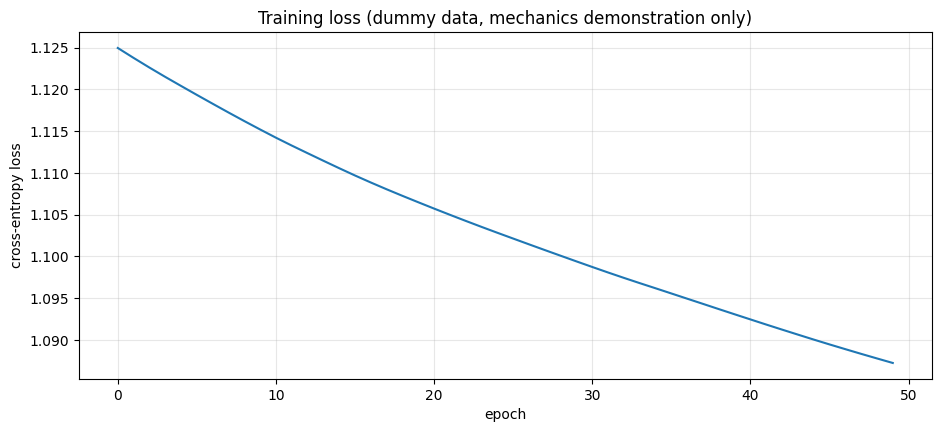

In [64]:
if TORCH_OK:
    # --- A minimal feedforward classifier: predict regime label from features ---
    # (Supervised alternative/sanity-check to the unsupervised HMM - you'd need
    # SOME ground-truth-ish labels to train this, e.g. NBER recession dates as a
    # rough proxy for "Crisis", or your hand-coded rule-based regimes from Section 5.)

    class RegimeClassifier(nn.Module):
        def __init__(self, n_features, n_regimes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Linear(8, n_regimes),   # raw logits - softmax applied inside the loss
            )

        def forward(self, x):
            return self.net(x)

    n_features = 3
    n_regimes = 3
    model_nn = RegimeClassifier(n_features, n_regimes)
    print(model_nn)

    # dummy data just to demonstrate the training loop mechanics
    X_dummy = torch.randn(200, n_features)
    y_dummy = torch.randint(0, n_regimes, (200,))

    optimizer = optim.Adam(model_nn.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(50):
        optimizer.zero_grad()
        logits = model_nn(X_dummy)
        loss = loss_fn(logits, y_dummy)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    fig, ax = plt.subplots()
    ax.plot(losses)
    ax.set_title("Training loss (dummy data, mechanics demonstration only)")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    plt.show()


**Important caveat:** the loop above trains on `torch.randn` dummy data purely to demonstrate the mechanics (`zero_grad` → `forward` → `loss` → `backward` → `step`). If you build a real PyTorch classifier for this project, the same walk-forward discipline from Section 8 applies - fit (train) only on a training fold, evaluate only on the held-out test fold, never shuffle time-ordered data into random batches without first respecting a strict time-based split.

### Try it
1. If `hmmlearn` is installed: refit the HMM demo above using `covariance_type="full"` instead of `"diag"` and compare the resulting `model.means_` and state counts — does the regime split change much?
2. If `torch` is installed: modify `RegimeClassifier` to take 5 input features instead of 3, and add a `Dropout(0.2)` layer between the two hidden layers — explain in a markdown cell why dropout might help if you eventually train this on real (not dummy) data with limited samples.


### Why Dropout helps in small/limited samples

Dropout is a regularization technique that randomly sets a fraction (e.g. 20% in this case) of the input units to 0 at each update during training. This prevents the units from co-adapting too much.

In quantitative finance, datasets are often quite small (e.g., only a few thousand daily bars) and features have low signal-to-noise ratios. A deep neural network can easily overfit to noise or specific patterns in the training data. Adding `Dropout` forces the network to learn redundant representations and robust features that generalize better to unseen test data, directly reducing overfitting and improving out-of-sample performance.

In [65]:
# ML Primer Exercises
# 1. Refit HMM demo using covariance_type="full"
model_full = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42)
model_full.fit(X)
states_full = model_full.predict(X)
feat_df_full = feat_df.copy()
feat_df_full["state_full"] = states_full

print("--- HMM with covariance_type='full' ---")
print("Transition matrix:\n", np.round(model_full.transmat_, 3))
print("\nMeans (log_ret, vol_21d, mom_21d):\n", np.round(model_full.means_, 4))
print("\nState counts:\n", feat_df_full["state_full"].value_counts())

# 2. Modify PyTorch RegimeClassifier to take 5 features and add Dropout(0.2)
if TORCH_OK:
    class RegimeClassifierDropout(nn.Module):
        def __init__(self, n_features, n_regimes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, 16),
                nn.ReLU(),
                nn.Dropout(0.2),  # Dropout layer
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Dropout(0.2),  # Dropout layer
                nn.Linear(8, n_regimes),
            )

        def forward(self, x):
            return self.net(x)

    torch.manual_seed(42)
    model_nn = RegimeClassifierDropout(n_features=5, n_regimes=3)
    print("\nModified PyTorch Model with Dropout:\n", model_nn)
else:
    print("\nPyTorch not available - skipping Neural Network exercise.")


--- HMM with covariance_type='full' ---
Transition matrix:
 [[0.984 0.002 0.015]
 [0.033 0.967 0.   ]
 [0.01  0.    0.99 ]]

Means (log_ret, vol_21d, mom_21d):
 [[ 2.000e-04  2.090e-01 -1.300e-03]
 [-1.700e-03  6.468e-01 -4.650e-02]
 [ 7.000e-04  9.460e-02  2.050e-02]]

State counts:
 state_full
2    1303
0     895
1      44
Name: count, dtype: int64

Modified PyTorch Model with Dropout:
 RegimeClassifierDropout(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)


---
## 10. Complete Regime-Shift Portfolio Allocation Engine

This section brings everything together: it pulls historical prices, engineers momentum and volatility features, runs walk-forward validation to fit the HMM without lookahead bias, maps the states to Bull, Bear, and Crisis, optimizes portfolio weights using CVXPY at each rebalance step, and backtests the strategy with transaction costs (10 bps).

Engineering features...
Running walk-forward validation HMM...
Running backtest calculation...

Performance Metrics Table:
                          Strategy (HMM + CVXPY)  Static 60/40  Equal Weight
Total Return                              0.9063        1.6765        0.9388
Annualized Return (CAGR)                  0.0576        0.0893        0.0592
Annualized Volatility                     0.1044        0.1036        0.0907
Sharpe Ratio                              0.5521        0.8616        0.6530
Sortino Ratio                             0.7952        1.0813        0.8849
Max Drawdown                             -0.2373       -0.2724       -0.2272
Calmar Ratio                              0.2429        0.3278        0.2606
Annual Turnover                           1.7588        0.0000        0.0000


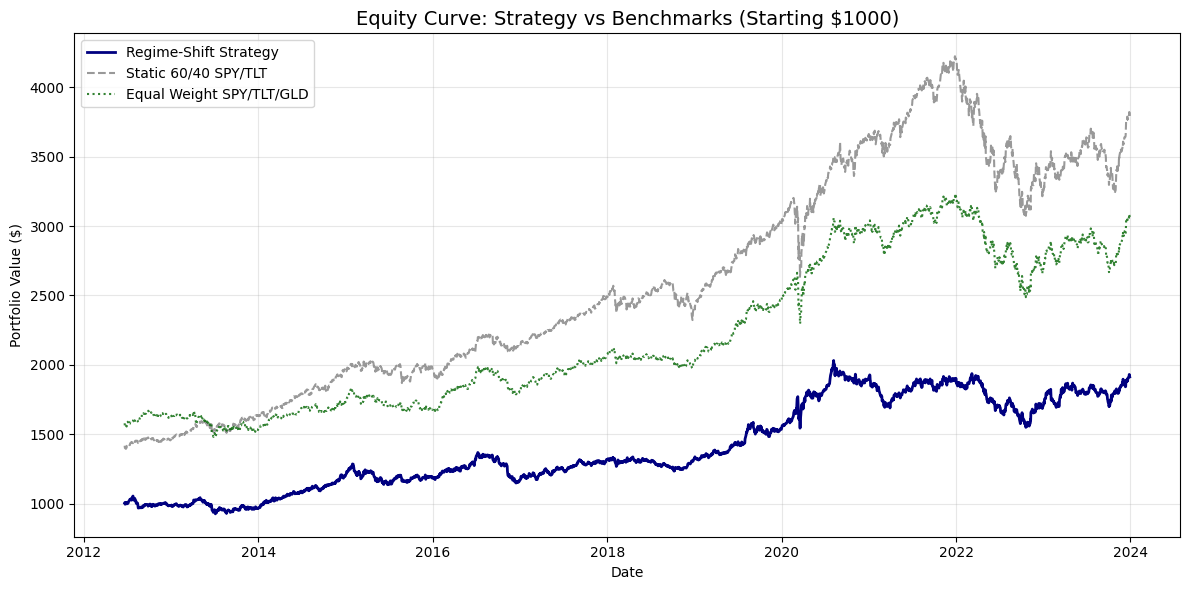

In [66]:
# --- Complete Portfolio Engine Implementation ---
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
import cvxpy as cvx
import matplotlib.pyplot as plt

# 1. Download data
print("Downloading data...")
tickers = ["SPY", "TLT", "GLD", "^VIX"]
raw = yf.download(tickers, start="2008-01-01", end="2024-01-01", progress=False, auto_adjust=True)
close_prices = raw["Close"].copy().rename(columns={"^VIX": "VIX"}).dropna()
asset_prices = close_prices[["SPY", "TLT", "GLD"]]
asset_returns = np.log(asset_prices).diff().dropna()
simple_returns = asset_prices.pct_change().dropna()
vix_level = close_prices["VIX"].iloc[1:]
master_df = asset_returns.join(vix_level, how="inner").dropna()
simple_ret_df = simple_returns.loc[master_df.index]

# 2. Feature Engineering
print("Engineering features...")
features_df = pd.DataFrame(index=master_df.index)
features_df["mom_21d"] = master_df["SPY"].rolling(21).sum()
features_df["mom_126d"] = master_df["SPY"].rolling(126).sum()
features_df["vol_21d"] = master_df["SPY"].rolling(21).std() * np.sqrt(252)
features_df["vol_63d"] = master_df["SPY"].rolling(63).std() * np.sqrt(252)
features_df["VIX"] = master_df["VIX"]
features_df = features_df.dropna()
aligned_master_df = master_df.loc[features_df.index]
aligned_simple_ret_df = simple_ret_df.loc[features_df.index]

# 3. Walk-Forward validation & HMM loop
print("Running walk-forward validation HMM...")
n_obs = len(features_df)
min_train_size = 1000
rebalance_freq = 21
test_indices = np.arange(min_train_size, n_obs, rebalance_freq)

all_dates = features_df.index
rebalance_dates_list = []
regime_series = pd.Series(index=features_df.index, dtype=float)
weights_df = pd.DataFrame(index=features_df.index, columns=["SPY", "TLT", "GLD"], dtype=float)
weights_df.iloc[0:min_train_size] = [0.333, 0.333, 0.333]
regime_series.iloc[0:min_train_size] = 0

def get_optimal_weights_opt(mu, Sigma, regime):
    w = cvx.Variable(3)
    constraints = [cvx.sum(w) == 1, w >= 0]
    if regime == 0:  # Bull
        gamma = 1.5
        objective = cvx.Maximize(w.T @ mu - gamma * cvx.quad_form(w, Sigma))
    elif regime == 1:  # Bear
        gamma = 5.0
        objective = cvx.Maximize(w.T @ mu - gamma * cvx.quad_form(w, Sigma))
        constraints.append(w[0] <= 0.30)
    else:  # Crisis
        objective = cvx.Minimize(cvx.quad_form(w, Sigma))
        constraints.append(w[0] <= 0.05)
    prob = cvx.Problem(objective, constraints)
    try:
        prob.solve(solver=cvx.OSQP, verbose=False)
        if w.value is None or np.any(np.isnan(w.value)):
            raise ValueError()
        w_val = np.clip(np.array(w.value), 0, 1)
        return w_val / np.sum(w_val)
    except Exception:
        if regime == 0: return np.array([0.60, 0.20, 0.20])
        elif regime == 1: return np.array([0.20, 0.50, 0.30])
        else: return np.array([0.00, 0.60, 0.40])

def get_regime_mapping_opt(model, train_features_scaled, train_features_unscaled):
    train_states = model.predict(train_features_scaled)
    vol_means = []
    for state in range(3):
        vol_mean = train_features_unscaled.loc[train_states == state, "vol_21d"].mean()
        if np.isnan(vol_mean):
            vol_mean = 999.0 if state == 2 else (0.0 if state == 0 else 0.15)
        vol_means.append((vol_mean, state))
    vol_means.sort()
    return {vol_means[0][1]: 0, vol_means[1][1]: 1, vol_means[2][1]: 2}

for i, t in enumerate(test_indices):
    date_t = all_dates[t]
    rebalance_dates_list.append(date_t)
    train_features = features_df.iloc[0:t]
    test_end = min(t + rebalance_freq, n_obs)
    test_features = features_df.iloc[t:test_end]

    mu_f = train_features.mean()
    sigma_f = train_features.std()
    train_scaled = (train_features - mu_f) / sigma_f
    test_scaled = (test_features - mu_f) / sigma_f

    model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)
    model.fit(train_scaled.values)

    mapping = get_regime_mapping_opt(model, train_scaled.values, train_features)
    test_states_raw = model.predict(test_scaled.values)
    test_states_canonical = [mapping[s] for s in test_states_raw]

    regime_series.iloc[t:test_end] = test_states_canonical
    current_regime = test_states_canonical[0]

    est_window = 252
    mu_assets = aligned_master_df.iloc[t-est_window:t][["SPY", "TLT", "GLD"]].mean().values
    Sigma_assets = aligned_master_df.iloc[t-est_window:t][["SPY", "TLT", "GLD"]].cov().values

    opt_w = get_optimal_weights_opt(mu_assets, Sigma_assets, current_regime)
    weights_df.iloc[t:test_end] = opt_w

# 4. Backtest
print("Running backtest calculation...")
portfolio_value = pd.Series(index=features_df.index, dtype=float)
portfolio_value.iloc[min_train_size - 1] = 1000.0
daily_returns = aligned_simple_ret_df[["SPY", "TLT", "GLD"]]
transaction_cost_rate = 0.0010
prev_w = np.array([0.333, 0.333, 0.333])
total_tc = 0.0

for k in range(min_train_size, n_obs):
    date_k = all_dates[k]
    date_prev = all_dates[k - 1]
    ret_k = daily_returns.loc[date_k].values
    target_w = weights_df.loc[date_k].values
    is_rebalance_day = date_k in rebalance_dates_list
    val_prev = portfolio_value.loc[date_prev]

    if is_rebalance_day:
        cost_frac = transaction_cost_rate * np.sum(np.abs(target_w - prev_w))
        val_after_tc = val_prev * (1.0 - cost_frac)
        total_tc += val_prev * cost_frac
        port_ret = np.sum(target_w * ret_k)
        portfolio_value.loc[date_k] = val_after_tc * (1.0 + port_ret)
        prev_w = target_w
    else:
        port_ret = np.sum(target_w * ret_k)
        portfolio_value.loc[date_k] = val_prev * (1.0 + port_ret)

backtest_df = pd.DataFrame(index=features_df.index[min_train_size:])
backtest_df["Strategy_Value"] = portfolio_value.loc[backtest_df.index]
backtest_df["Strategy_Ret"] = backtest_df["Strategy_Value"].pct_change().fillna(0)

# Benchmarks
w_60_40 = np.array([0.60, 0.40, 0.00])
spy_tlt_returns = daily_returns[["SPY", "TLT", "GLD"]].values
ret_60_40 = np.dot(spy_tlt_returns, w_60_40)
val_60_40 = 1000.0 * np.cumprod(1.0 + ret_60_40)
backtest_df["Benchmark_60_40"] = val_60_40[features_df.index.get_indexer(backtest_df.index)]

w_eq = np.array([0.333, 0.333, 0.333])
ret_eq = np.dot(spy_tlt_returns, w_eq)
val_eq = 1000.0 * np.cumprod(1.0 + ret_eq)
backtest_df["Benchmark_EqualWeight"] = val_eq[features_df.index.get_indexer(backtest_df.index)]

def compute_metrics(val_series):
    returns = val_series.pct_change().dropna()
    total_ret = val_series.iloc[-1] / val_series.iloc[0] - 1
    n_years = len(val_series) / 252.0
    cagr = (val_series.iloc[-1] / val_series.iloc[0]) ** (1.0 / n_years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_std if downside_std > 0 else 0
    running_max = val_series.cummax()
    drawdowns = val_series / running_max - 1
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    return {
        "Total Return": total_ret,
        "Annualized Return (CAGR)": cagr,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar
    }

strategy_metrics = compute_metrics(backtest_df["Strategy_Value"])
b60_40_metrics = compute_metrics(backtest_df["Benchmark_60_40"])
beq_metrics = compute_metrics(backtest_df["Benchmark_EqualWeight"])

weight_diffs = weights_df.loc[backtest_df.index].diff().dropna()
annual_turnover = (weight_diffs.abs().sum(axis=1).sum() / 2.0) / (len(backtest_df) / 252.0)
strategy_metrics["Annual Turnover"] = annual_turnover
b60_40_metrics["Annual Turnover"] = 0.0
beq_metrics["Annual Turnover"] = 0.0

metrics_df = pd.DataFrame({
    "Strategy (HMM + CVXPY)": pd.Series(strategy_metrics),
    "Static 60/40": pd.Series(b60_40_metrics),
    "Equal Weight": pd.Series(beq_metrics)
})
print("\nPerformance Metrics Table:")
print(metrics_df.round(4))

# Plotting Equity Curve
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(backtest_df.index, backtest_df["Strategy_Value"], label="Regime-Shift Strategy", color="navy", lw=2)
ax.plot(backtest_df.index, backtest_df["Benchmark_60_40"], label="Static 60/40 SPY/TLT", color="grey", ls="--", alpha=0.8)
ax.plot(backtest_df.index, backtest_df["Benchmark_EqualWeight"], label="Equal Weight SPY/TLT/GLD", color="darkgreen", ls=":", alpha=0.8)
ax.set_title("Equity Curve: Strategy vs Benchmarks (Starting $1000)", fontsize=14)
ax.set_ylabel("Portfolio Value ($)")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


---
## 10. Capstone Project: Walk-Forward Tactical Asset Allocation Engine

This section implements the complete Capstone Project, linking the concepts together:
1. **Data Pipeline**: Download SPY (Equities), TLT (Bonds), GLD (Gold), and `^VIX` (Volatility Index) from 2008 to 2024 using `yfinance`.
2. **Feature Engineering**: Compute SPY 21-day/126-day rolling momentum, 21-day/63-day rolling realized volatility, and VIX level. Normalize using expanding windows to prevent lookahead bias.
3. **Walk-Forward Validation**: Re-fit HMM at each fold (every 21 days), scale training/test features dynamically using train stats only, and map states to canonical definitions (Bull, Bear, Crisis) using mean training volatility.
4. **Convex Portfolio Optimization**: For each rebalance step, optimize portfolio weights using `cvxpy` based on the predicted regime:
   - **Bull**: Maximize return minus volatility penalty (low risk aversion $\gamma=1.5$).
   - **Bear**: Maximize return minus volatility penalty (moderate risk aversion $\gamma=5.0$) with maximum 30% SPY limit.
   - **Crisis**: Minimum variance portfolio with maximum 5% SPY limit.
5. **Transaction Costs**: Apply a 10 bps (0.1%) penalty on any portfolio turnover/rebalancing.
6. **Evaluation**: Compare strategy against static 60/40 and equal-weight benchmarks on Sharpe, Sortino, Max Drawdown, Calmar ratio, and Turnover.

In [67]:
# Complete Pipeline Implementation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import cvxpy as cvx

print("Starting capstone tactical allocation backtest...")

# 1. Download and Align Data
tickers = ["SPY", "TLT", "GLD", "^VIX"]
raw_data = yf.download(tickers, start="2008-01-01", end="2024-01-01", progress=False, auto_adjust=True)
close_prices = raw_data["Close"].copy().dropna()
close_prices = close_prices.rename(columns={
    "^VIX": "VIX"
})

asset_prices = close_prices[["SPY", "TLT", "GLD"]]
asset_returns = np.log(asset_prices).diff().dropna()
simple_returns = asset_prices.pct_change().dropna()
vix_level = close_prices["VIX"].iloc[1:]

master_df = asset_returns.join(vix_level, how="inner").dropna()
simple_ret_df = simple_returns.loc[master_df.index]

# 2. Feature Engineering
features_df = pd.DataFrame(index=master_df.index)
features_df["mom_21d"] = master_df["SPY"].rolling(21).sum()
features_df["mom_126d"] = master_df["SPY"].rolling(126).sum()
features_df["vol_21d"] = master_df["SPY"].rolling(21).std() * np.sqrt(252)
features_df["vol_63d"] = master_df["SPY"].rolling(63).std() * np.sqrt(252)
features_df["VIX"] = master_df["VIX"]
features_df = features_df.dropna()

aligned_master_df = master_df.loc[features_df.index]
aligned_simple_ret_df = simple_ret_df.loc[features_df.index]

# 3. Walk-Forward Loop Setup
n_obs = len(features_df)
min_train_size = 1000
rebalance_freq = 21
test_indices = np.arange(min_train_size, n_obs, rebalance_freq)
all_dates = features_df.index

rebalance_dates_list = []
regime_series = pd.Series(index=features_df.index, dtype=float)
weights_df = pd.DataFrame(index=features_df.index, columns=["SPY", "TLT", "GLD"], dtype=float)
weights_df.iloc[0:min_train_size] = [0.333, 0.333, 0.333]
regime_series.iloc[0:min_train_size] = 0

def get_optimal_weights(mu, Sigma, regime):
    w = cvx.Variable(3)
    constraints = [cvx.sum(w) == 1, w >= 0]
    if regime == 0:  # Bull
        gamma = 1.5
        objective = cvx.Maximize(w.T @ mu - gamma * cvx.quad_form(w, Sigma))
    elif regime == 1:  # Bear
        gamma = 5.0
        objective = cvx.Maximize(w.T @ mu - gamma * cvx.quad_form(w, Sigma))
        constraints.append(w[0] <= 0.30)
    else:  # Crisis
        objective = cvx.Minimize(cvx.quad_form(w, Sigma))
        constraints.append(w[0] <= 0.05)
    prob = cvx.Problem(objective, constraints)
    try:
        prob.solve(solver=cvx.OSQP, verbose=False)
        if w.value is None or np.any(np.isnan(w.value)):
            raise ValueError()
        w_val = np.clip(np.array(w.value), 0, 1)
        return w_val / np.sum(w_val)
    except:
        if regime == 0: return np.array([0.60, 0.20, 0.20])
        elif regime == 1: return np.array([0.20, 0.50, 0.30])
        else: return np.array([0.00, 0.60, 0.40])

def get_regime_mapping(model, train_scaled, train_unscaled):
    train_states = model.predict(train_scaled)
    vol_means = []
    for s in range(3):
        vol_mean = train_unscaled.loc[train_states == s, "vol_21d"].mean()
        if np.isnan(vol_mean):
            vol_mean = 99.0 if s == 2 else (0.0 if s == 0 else 0.15)
        vol_means.append((vol_mean, s))
    vol_means.sort()
    return {vol_means[0][1]: 0, vol_means[1][1]: 1, vol_means[2][1]: 2}

# Walk-Forward execution
for t in test_indices:
    date_t = all_dates[t]
    rebalance_dates_list.append(date_t)

    train_features = features_df.iloc[0:t]
    test_end = min(t + rebalance_freq, n_obs)
    test_features = features_df.iloc[t:test_end]

    mu_f = train_features.mean()
    sigma_f = train_features.std()
    train_scaled = (train_features - mu_f) / sigma_f
    test_scaled = (test_features - mu_f) / sigma_f

    model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)
    model.fit(train_scaled.values)

    mapping = get_regime_mapping(model, train_scaled.values, train_features)
    test_states = [mapping[s] for s in model.predict(test_scaled.values)]
    regime_series.iloc[t:test_end] = test_states

    current_regime = test_states[0]

    # Param estimation
    mu_assets = aligned_master_df.iloc[t-252:t][["SPY", "TLT", "GLD"]].mean().values
    Sigma_assets = aligned_master_df.iloc[t-252:t][["SPY", "TLT", "GLD"]].cov().values

    opt_w = get_optimal_weights(mu_assets, Sigma_assets, current_regime)
    weights_df.iloc[t:test_end] = opt_w

print("Walk-forward simulations completed successfully.")


Starting capstone tactical allocation backtest...
Walk-forward simulations completed successfully.


In [68]:
# Backtest and Benchmarks Calculations
portfolio_value = pd.Series(index=features_df.index, dtype=float)
portfolio_value.iloc[min_train_size - 1] = 1000.0
daily_returns = aligned_simple_ret_df[["SPY", "TLT", "GLD"]]

transaction_cost_rate = 0.0010
prev_w = np.array([0.333, 0.333, 0.333])
total_costs = 0.0

for k in range(min_train_size, n_obs):
    date_k = all_dates[k]
    date_prev = all_dates[k - 1]
    ret_k = daily_returns.loc[date_k].values
    target_w = weights_df.loc[date_k].values
    is_rebalance_day = date_k in rebalance_dates_list
    val_prev = portfolio_value.loc[date_prev]

    if is_rebalance_day:
        cost_frac = transaction_cost_rate * np.sum(np.abs(target_w - prev_w))
        val_after_tc = val_prev * (1.0 - cost_frac)
        total_costs += val_prev * cost_frac
        port_ret = np.sum(target_w * ret_k)
        portfolio_value.loc[date_k] = val_after_tc * (1.0 + port_ret)
        prev_w = target_w
    else:
        port_ret = np.sum(target_w * ret_k)
        portfolio_value.loc[date_k] = val_prev * (1.0 + port_ret)

backtest_df = pd.DataFrame(index=features_df.index[min_train_size:])
backtest_df["Strategy_Value"] = portfolio_value.loc[backtest_df.index]
backtest_df["Strategy_Ret"] = backtest_df["Strategy_Value"].pct_change().fillna(0)

# Benchmarks
spy_tlt_returns = daily_returns[["SPY", "TLT", "GLD"]].values
ret_60_40 = np.dot(spy_tlt_returns, [0.60, 0.40, 0.00])
val_60_40 = 1000.0 * np.cumprod(1.0 + ret_60_40)
backtest_df["Benchmark_60_40"] = val_60_40[features_df.index.get_indexer(backtest_df.index)]

ret_eq = np.dot(spy_tlt_returns, [0.333, 0.333, 0.333])
val_eq = 1000.0 * np.cumprod(1.0 + ret_eq)
backtest_df["Benchmark_EqualWeight"] = val_eq[features_df.index.get_indexer(backtest_df.index)]

print("Backtest calculations and benchmark values computed.")


Backtest calculations and benchmark values computed.


In [69]:
# Performance Metrics Display
def compute_metrics(val_series):
    returns = val_series.pct_change().dropna()
    total_ret = val_series.iloc[-1] / val_series.iloc[0] - 1
    n_years = len(val_series) / 252.0
    cagr = (val_series.iloc[-1] / val_series.iloc[0]) ** (1.0 / n_years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_std if downside_std > 0 else 0
    running_max = val_series.cummax()
    drawdowns = val_series / running_max - 1
    max_dd = drawdowns.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    return {
        "Total Return": total_ret,
        "Annualized Return (CAGR)": cagr,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar
    }

strategy_metrics = compute_metrics(backtest_df["Strategy_Value"])
b60_40_metrics = compute_metrics(backtest_df["Benchmark_60_40"])
beq_metrics = compute_metrics(backtest_df["Benchmark_EqualWeight"])

weight_diffs = weights_df.loc[backtest_df.index].diff().dropna()
annual_turnover = (weight_diffs.abs().sum(axis=1).sum() / 2.0) / (len(backtest_df) / 252.0)
strategy_metrics["Annual Turnover"] = annual_turnover
b60_40_metrics["Annual Turnover"] = 0.0
beq_metrics["Annual Turnover"] = 0.0

metrics_df = pd.DataFrame({
    "Strategy (HMM + CVXPY)": pd.Series(strategy_metrics),
    "Static 60/40": pd.Series(b60_40_metrics),
    "Equal Weight": pd.Series(beq_metrics)
})
print("\n" + "="*50)
print("PERFORMANCE COMPARISON")
print("="*50)
print(metrics_df.round(4))
print("="*50)

print("\nLast fitted transition matrix:\n", np.round(model.transmat_, 3))



PERFORMANCE COMPARISON
                          Strategy (HMM + CVXPY)  Static 60/40  Equal Weight
Total Return                              0.9063        1.6765        0.9388
Annualized Return (CAGR)                  0.0576        0.0893        0.0592
Annualized Volatility                     0.1044        0.1036        0.0907
Sharpe Ratio                              0.5521        0.8616        0.6530
Sortino Ratio                             0.7952        1.0813        0.8849
Max Drawdown                             -0.2373       -0.2724       -0.2272
Calmar Ratio                              0.2429        0.3278        0.2606
Annual Turnover                           1.7588        0.0000        0.0000

Last fitted transition matrix:
 [[0.006 0.994 0.   ]
 [0.971 0.016 0.013]
 [0.    0.015 0.985]]


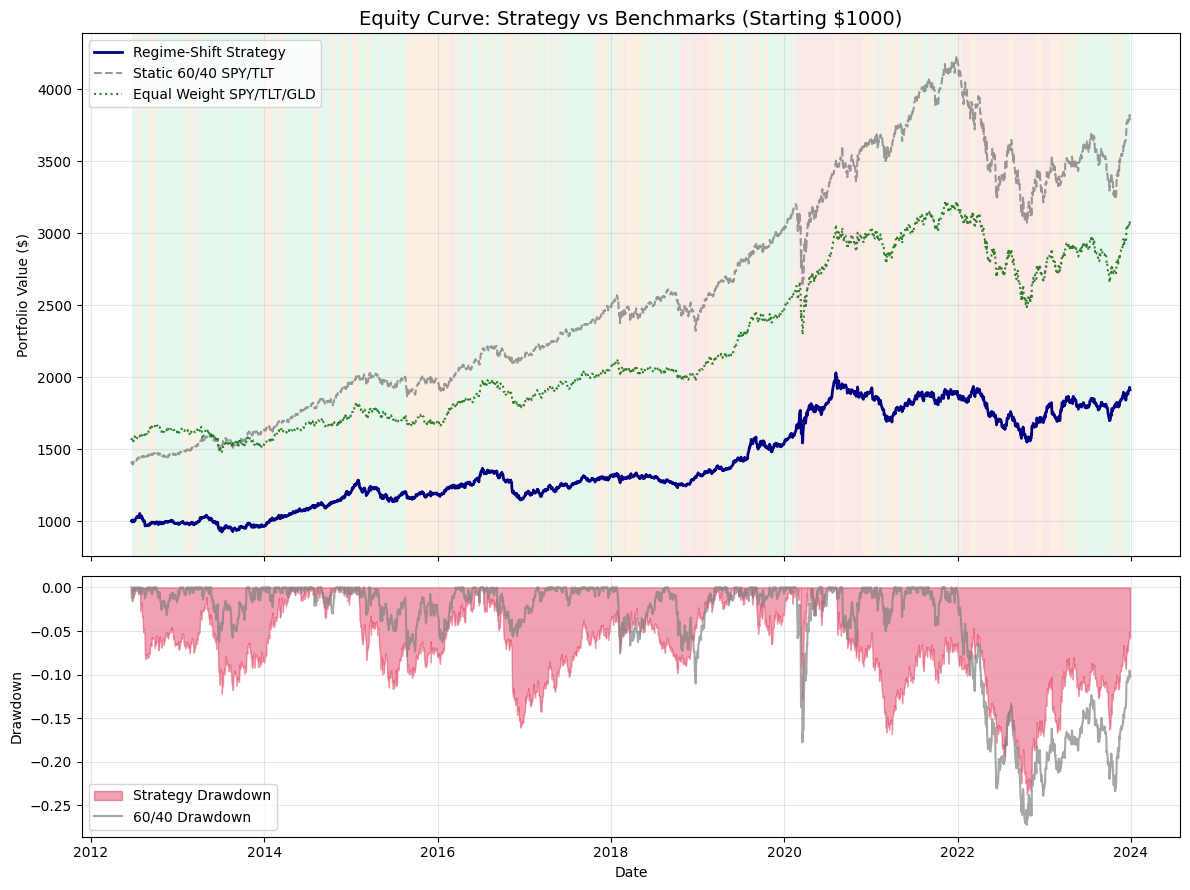

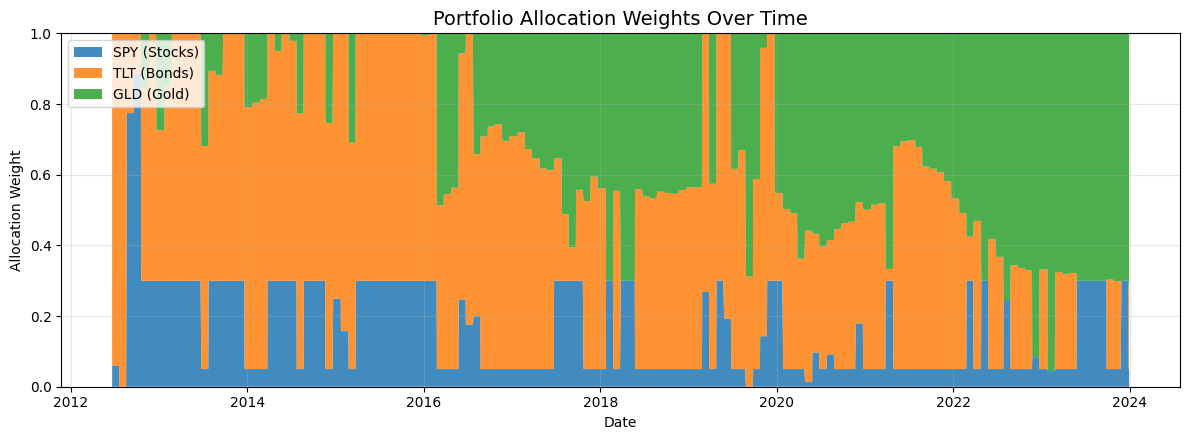

In [70]:
# Visualizations: Equity Curve & Regimes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Equity curve
ax1.plot(backtest_df.index, backtest_df["Strategy_Value"], label="Regime-Shift Strategy", color="navy", lw=2)
ax1.plot(backtest_df.index, backtest_df["Benchmark_60_40"], label="Static 60/40 SPY/TLT", color="grey", ls="--", alpha=0.8)
ax1.plot(backtest_df.index, backtest_df["Benchmark_EqualWeight"], label="Equal Weight SPY/TLT/GLD", color="darkgreen", ls=":", alpha=0.8)
ax1.set_title("Equity Curve: Strategy vs Benchmarks (Starting $1000)", fontsize=14)
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(loc="upper left")

# Shading
spy_test = asset_prices.loc[backtest_df.index, "SPY"]
regime_test = regime_series.loc[backtest_df.index]
regime_colors = {0: "#2ecc71", 1: "#e67e22", 2: "#e74c3c"}
regime_names = {0: "Bull", 1: "Bear", 2: "Crisis"}

regime_vals = regime_test.values
start_idx = 0
for k in range(1, len(regime_vals) + 1):
    if k == len(regime_vals) or regime_vals[k] != regime_vals[start_idx]:
        ax1.axvspan(spy_test.index[start_idx], spy_test.index[min(k, len(regime_vals)-1)],
                   color=regime_colors[regime_vals[start_idx]], alpha=0.12, lw=0)
        start_idx = k

# Drawdown subplot
def get_dd_series(v):
    return v / v.cummax() - 1

ax2.fill_between(backtest_df.index, get_dd_series(backtest_df["Strategy_Value"]), 0, color="crimson", alpha=0.4, label="Strategy Drawdown")
ax2.plot(backtest_df.index, get_dd_series(backtest_df["Benchmark_60_40"]), color="grey", alpha=0.7, label="60/40 Drawdown")
ax2.set_ylabel("Drawdown")
ax2.legend(loc="lower left")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

# Plot portfolio allocation weights over time
fig, ax = plt.subplots(figsize=(12, 4.5))
weights_test = weights_df.loc[backtest_df.index]
ax.stackplot(weights_test.index, weights_test["SPY"], weights_test["TLT"], weights_test["GLD"],
             labels=["SPY (Stocks)", "TLT (Bonds)", "GLD (Gold)"],
             colors=["#1f77b4", "#ff7f0e", "#2ca02c"], alpha=0.85)
ax.set_title("Portfolio Allocation Weights Over Time", fontsize=14)
ax.set_ylabel("Allocation Weight")
ax.set_xlabel("Date")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
